<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/02_Airbnb_Berlin_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
# !pip install missingno
# !pip install autoviz
# !pip install geopy
# !pip install scipy
# !pandas_profiling
# !pip install statsmodels
# !pip install pyodbc
# !pip install seaborn
# !pip install nltk

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Defines data columns Lists

In [109]:
numerical_columns = ['Price','Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time']
date_columns = ['review_date','Host Since']
non_categorical_columns = numerical_columns + rating_columns + boolean_columns

In [110]:
df_EDA = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA.pkl')

In [111]:
df = df_EDA.copy()
df.reset_index(drop=True, inplace=True)
# df.shape, df.index[-1]

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        18888 non-null  float64
 1   Bathrooms              23507 non-null  float64
 2   Checkin Rating         18870 non-null  float64
 3   Cleanliness Rating     18892 non-null  float64
 4   Communication Rating   18886 non-null  float64
 5   Host Response Rate     13046 non-null  float64
 6   Latitude               23536 non-null  float64
 7   Location Rating        18871 non-null  float64
 8   Longitude              23536 non-null  float64
 9   Overall Rating         18914 non-null  float64
 10  Price                  23536 non-null  float64
 11  Square Feet            425 non-null    float64
 12  Value Rating           18868 non-null  float64
 13  review_date            19380 non-null  object 
 14  Comments               19378 non-null  object 
 15  Ho

# EDA - Explenatory Data Analysis

In [113]:
df.head(2)

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,review_date,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,10.0,1.0,10.0,10.0,10.0,50.0,52.54851,9.0,13.40455,100.0,17.0,NaN,10.0,07-04-18,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2,1.0,1.0,1,2,7,Apartment,10
1,9.0,1.0,9.0,9.0,9.0,50.0,52.53500,10.0,13.41758,92.0,90.0,720.0,9.0,06-20-09,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4,1.0,2.0,2,62,144,Apartment,10


## Data Protocol

In [114]:
#Type of data
df.dtypes.to_excel ("df_datatype.xlsx", sheet_name='data_types')

#Maximum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='max')

#Minimum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='min')

#Isnull values
df.isnull().to_excel("df_isnull.xlsx", sheet_name='isnull')

#unique values
df.nunique().to_excel("df_nunique.xlsx", sheet_name='nunique')

# Categorical values
df[categorical_columns].describe().to_excel("df_categorical.xlsx", sheet_name='categorical')

In [115]:
# from autoviz.AutoViz_Class import AutoViz_Class
# %matplotlib inline

# AV = AutoViz_Class()
# AV.AutoViz(df)

**commented out AtuoViz because teh size of the file was too big for github to present**

## Descriptive statistics
   

In [116]:
df.shape

(23536, 33)

In [117]:
df[numerical_columns].describe()

,Price,Accomodates,Bathrooms,Bedrooms,Beds,Guests Included,Min Nights,Reviews
count,23536.000000,23536.000000,23507.000000,23516.000000,23501.000000,23536.000000,23536.000000,23536.000000
mean,69.612424,2.671737,1.095971,1.161720,1.641802,1.346151,6.897774,19.238826
std,216.660408,1.567812,0.346150,0.660736,1.228642,0.856297,24.879032,40.360483
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,32.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
50%,49.000000,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,5.000000
75%,75.000000,3.000000,1.000000,1.000000,2.000000,1.000000,4.000000,17.000000
max,9000.000000,16.000000,8.500000,10.000000,22.000000,16.000000,1000.000000,545.000000


In [118]:
df[rating_columns].describe()

,Value Rating,Location Rating,Cleanliness Rating,Checkin Rating,Accuracy Rating,Communication Rating,Host Response Rate,Overall Rating
count,18868.000000,18871.000000,18892.000000,18870.000000,18888.000000,18886.000000,13046.000000,18914.000000
mean,9.417638,9.550315,9.334904,9.728829,9.679850,9.746479,91.842174,94.564344
std,0.840456,0.748713,1.031248,0.695275,0.737798,0.679600,19.447852,7.599949
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,20.000000
25%,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000,95.000000,92.000000
50%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,97.000000
75%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000


In [119]:
df[boolean_columns].describe()

,Is Superhost,Is Exact Location,Instant Bookable
count,23536,23536,23536
unique,2,2,2
top,False,True,False
freq,19969,17649,15658


In [120]:
df[categorical_columns].describe()

,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
count,23536,23536,23536,23536,13046
unique,3,15,12,8,4
top,Private room,Apartment,Friedrichshain-Kreuzberg,10,within an hour
freq,11694,20935,5726,14667,6816


In [121]:
# df[['Host Since Year', 'Host Since Month', 'Host Since Day']].describe()

Several rows with unusually high values can be identified and may in some cases be dropped at a certain threshold

The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

In [122]:
df[['Beds', 'Min Nights', 'Reviews', 'Price']].describe().loc[['max']].T

,max
Beds,22.0
Min Nights,1000.0
Reviews,545.0
Price,9000.0


## Target Value

In [123]:
df[['Price']].describe()

,Price
count,23536.000000
mean,69.612424
std,216.660408
min,0.000000
25%,32.000000
50%,49.000000
75%,75.000000
max,9000.000000


The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

### Distribution of Price

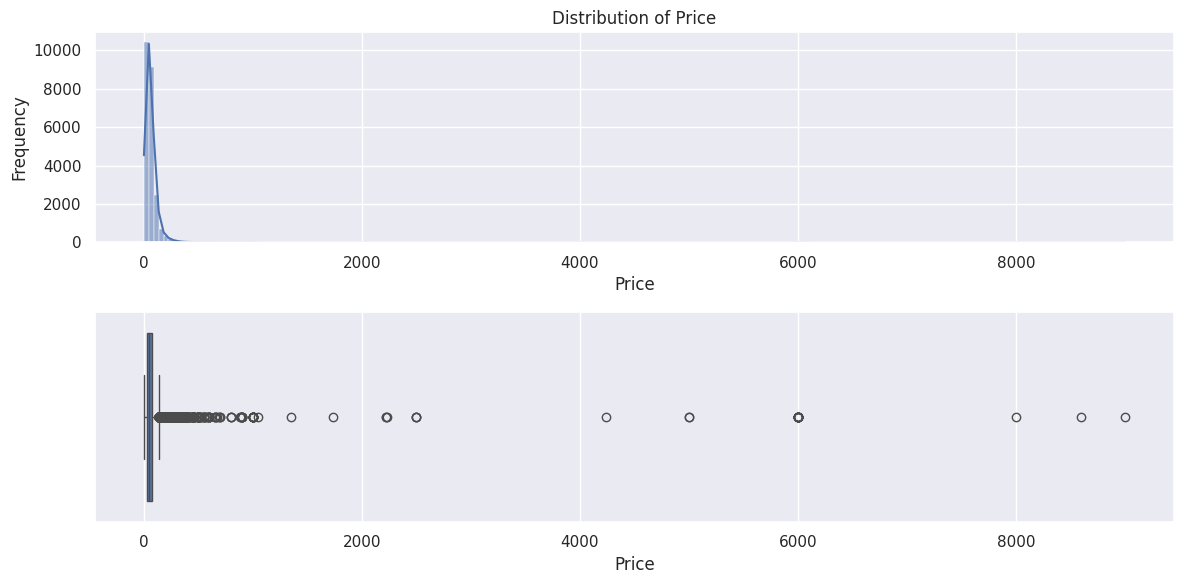

In [124]:
def target_value_distributions(df):
  plt.figure(figsize=(12, 6))
  plt.subplot(2, 1, 1)
  sns.histplot(df['Price'], bins=200, kde=True)
  plt.title("Distribution of Price")
  plt.xlabel("Price")
  plt.ylabel("Frequency")

  plt.subplot(2, 1, 2)
  sns.boxplot(df['Price'], orient='h')
  plt.xlabel("Price")

  plt.tight_layout()
  plt.show()

# Distribution of Price before dropping extream outlier values
target_value_distributions(df)

In [125]:
df['Price'].describe()

,Price
count,23536.000000
mean,69.612424
std,216.660408
min,0.000000
25%,32.000000
50%,49.000000
75%,75.000000
max,9000.000000


The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

To exclude the outlinear in this dataset, we set the data limit of 600€.

It also shows that data has 0 price, that is not make sense. So we will exclude it too.

In [126]:
df = df[(df['Price'] <= 600) & (df['Price'] > 0)]
df['Price'].describe()

,Price
count,23460.000000
mean,60.926726
std,49.445524
min,1.000000
25%,31.000000
50%,49.000000
75%,74.000000
max,600.000000


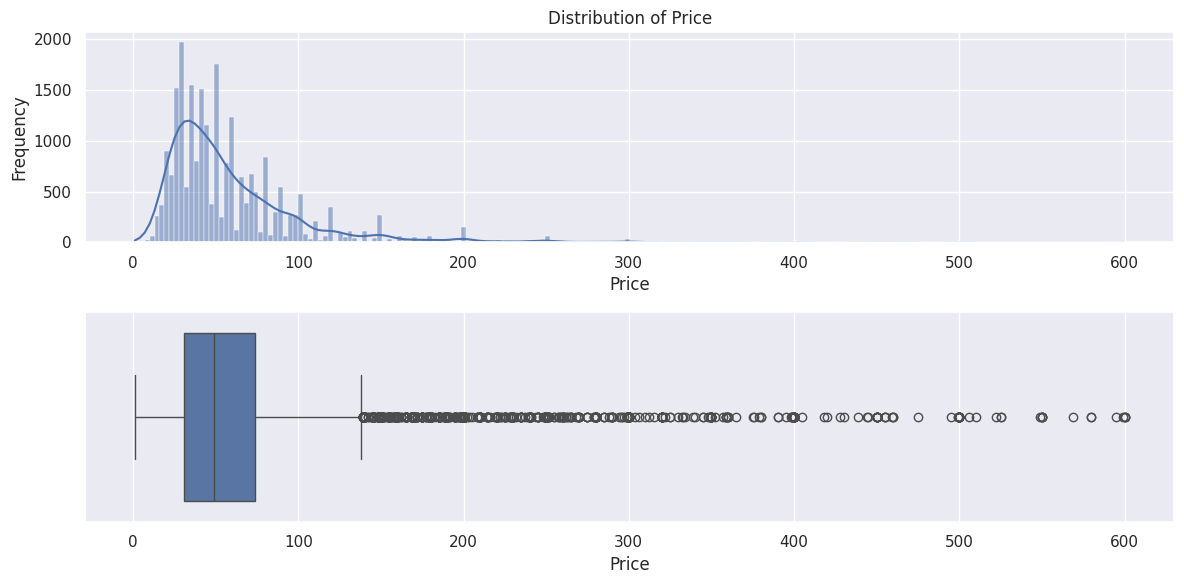

In [127]:
# Distribution of Price after cleaning extream outlier
target_value_distributions(df)

### Location vs Price

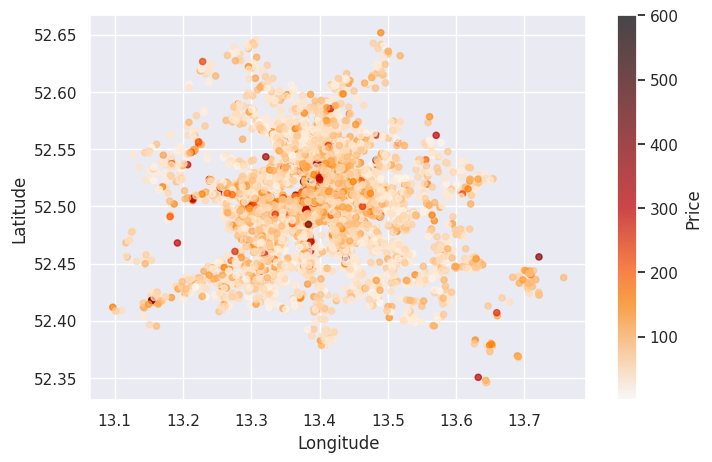

In [128]:
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.7, figsize=(8,5),
        c="Price", cmap="gist_heat_r", colorbar=True, sharex=False);

In [129]:
df.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'review_date', 'Comments', 'Host Since',
       'Host Response Time', 'Is Superhost', 'neighbourhood',
       'Neighborhood Group', 'Postal Code', 'Is Exact Location',
       'Property Type', 'Room Type', 'Instant Bookable', 'Accomodates',
       'Bedrooms', 'Beds', 'Guests Included', 'Min Nights', 'Reviews',
       'Property Type Reduced', 'Postal Code Reduced'],
      dtype='object')

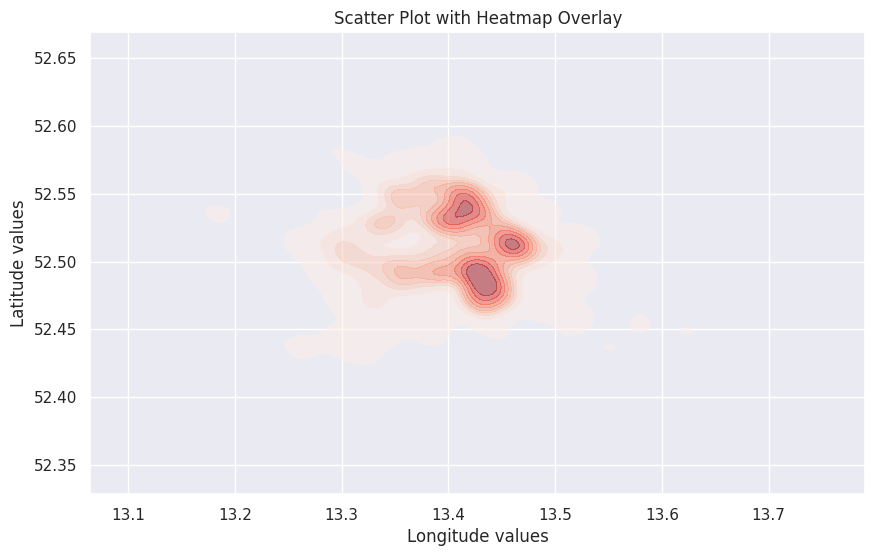

In [130]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot the heatmap using KDE (Kernel Density Estimation)
sns.kdeplot(x=df["Longitude"], y=df["Latitude"], cmap="Reds", fill=True, alpha=0.5)

# Overlay scatter plot
# sns.scatterplot(x=df["Longitude"], y=df["Latitude"], color="blue", alpha=0.5, cmap="viridis")
# sns.scatterplot(data=df, x="Longitude", y="Latitude", color="blue", alpha=0.5, cmap="viridis")
# sns.scatterplot(data=df, x="Longitude", y="Latitude", color="blue", alpha=0.5, size='Price' )

# Labels and title
plt.xlabel("Longitude values")
plt.ylabel("Latitude values")
plt.title("Scatter Plot with Heatmap Overlay")

# Show the plot
plt.show()


## Missing values

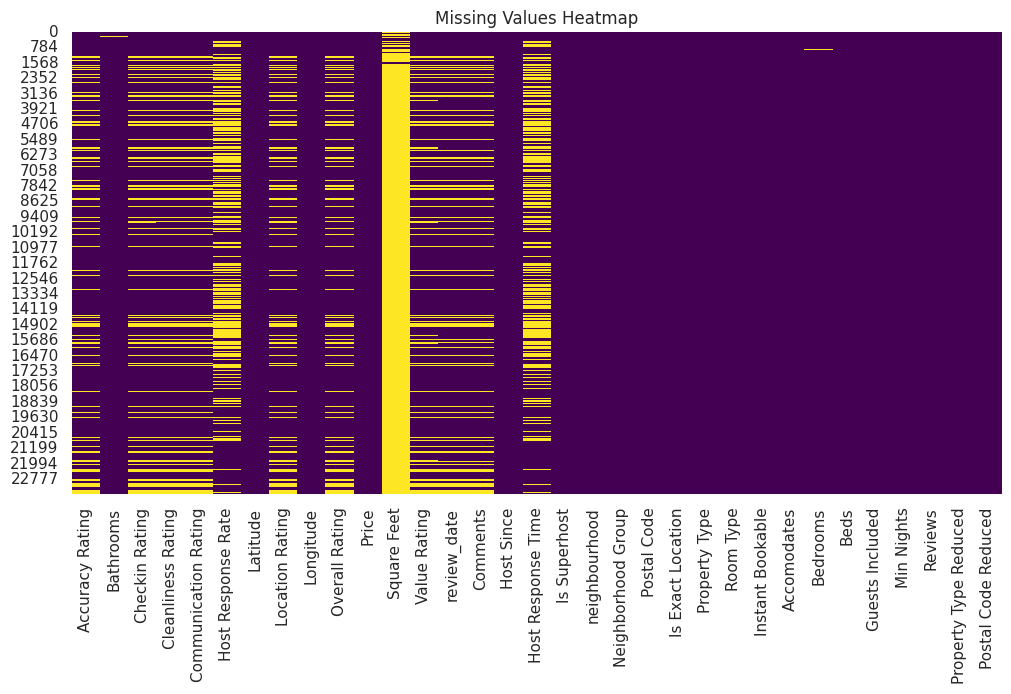

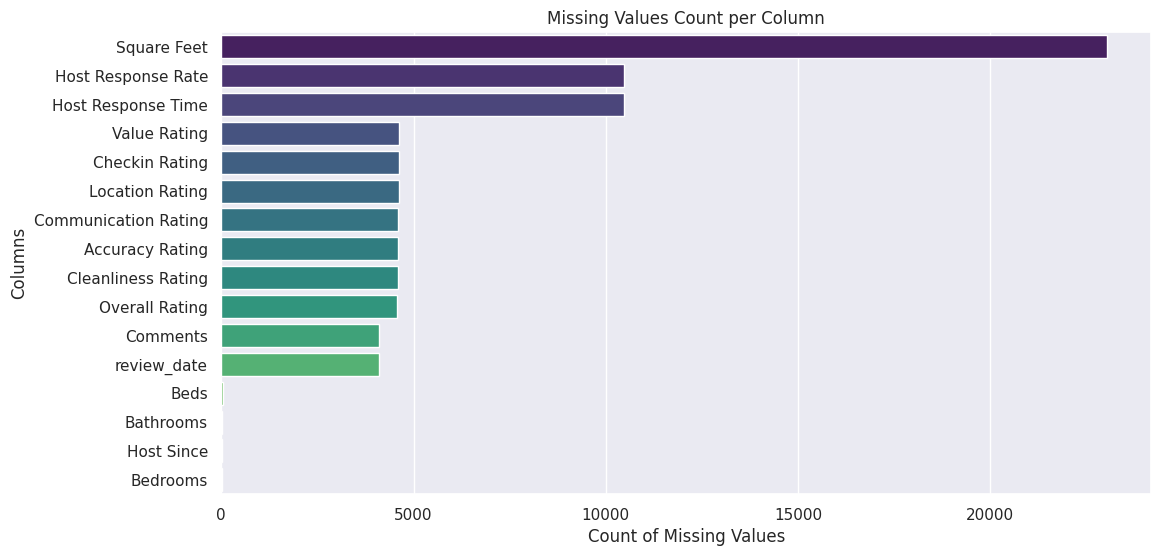


Missing Values:
Square Feet             23035
Host Response Rate      10476
Host Response Time      10476
Value Rating             4618
Checkin Rating           4616
Location Rating          4615
Communication Rating     4600
Accuracy Rating          4598
Cleanliness Rating       4594
Overall Rating           4572
Comments                 4110
review_date              4108
Beds                       34
Bathrooms                  29
Host Since                 20
Bedrooms                   20
dtype: int64


In [131]:
# Check for missing values
missing_values = df.isnull().sum()

# Visualizing missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Display missing values as a bar chart
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette="viridis")
plt.xlabel("Count of Missing Values")
plt.ylabel("Columns")
plt.title("Missing Values Count per Column")
plt.show()


print("\nMissing Values:")
print(missing_values)

## Dummies

In [132]:
def plot_counts_for_columns(df, columns_names, rows=1, cols=3, figsize_=(20, 6)):
  i = 1
  plt.figure(figsize=figsize_)
  plt.subplots_adjust(hspace = 0.5)
  for col in columns_names:
    plt.subplot(rows, cols, i)
    plt.title(f"'{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    sns.countplot(data=df, x=col, palette="viridis")
    i = i + 1

  plt.tight_layout()
  plt.show()
  print (i)

In [133]:
boolean_columns

['Is Superhost', 'Is Exact Location', 'Instant Bookable']

In [134]:
df['Is Superhost'] = df['Is Superhost'].astype(bool)
df[boolean_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Is Superhost       23460 non-null  bool 
 1   Is Exact Location  23460 non-null  bool 
 2   Instant Bookable   23460 non-null  bool 
dtypes: bool(3)
memory usage: 252.0 KB


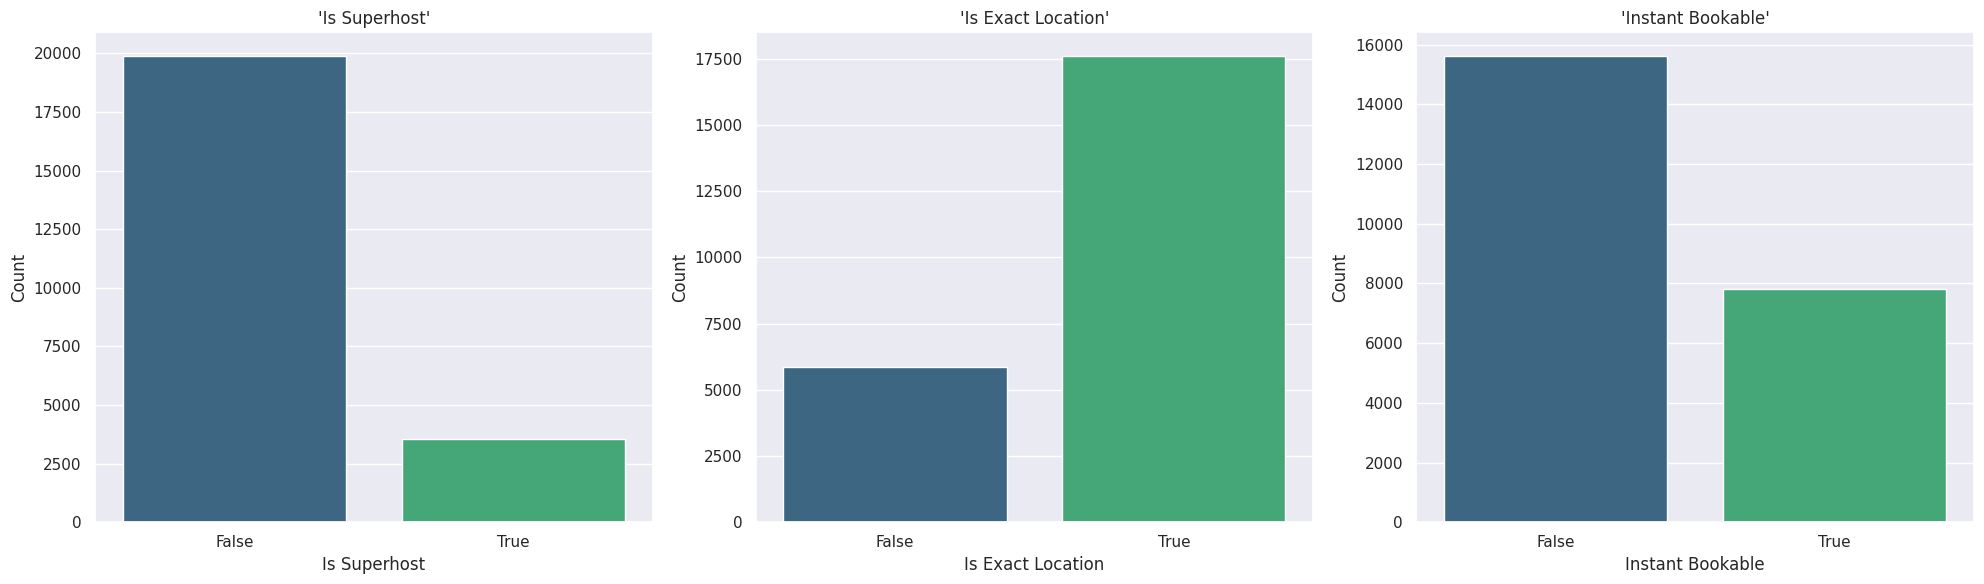

4


In [135]:
plot_counts_for_columns(df, boolean_columns)

## Categorial

In [136]:
df[categorical_columns].describe().T

,count,unique,top,freq
Room Type,23460,3,Private room,11658
Property Type Reduced,23460,15,Apartment,20914
Neighborhood Group,23460,12,Friedrichshain-Kreuzberg,5720
Postal Code Reduced,23460,8,10,14613
Host Response Time,12984,4,within an hour,6780


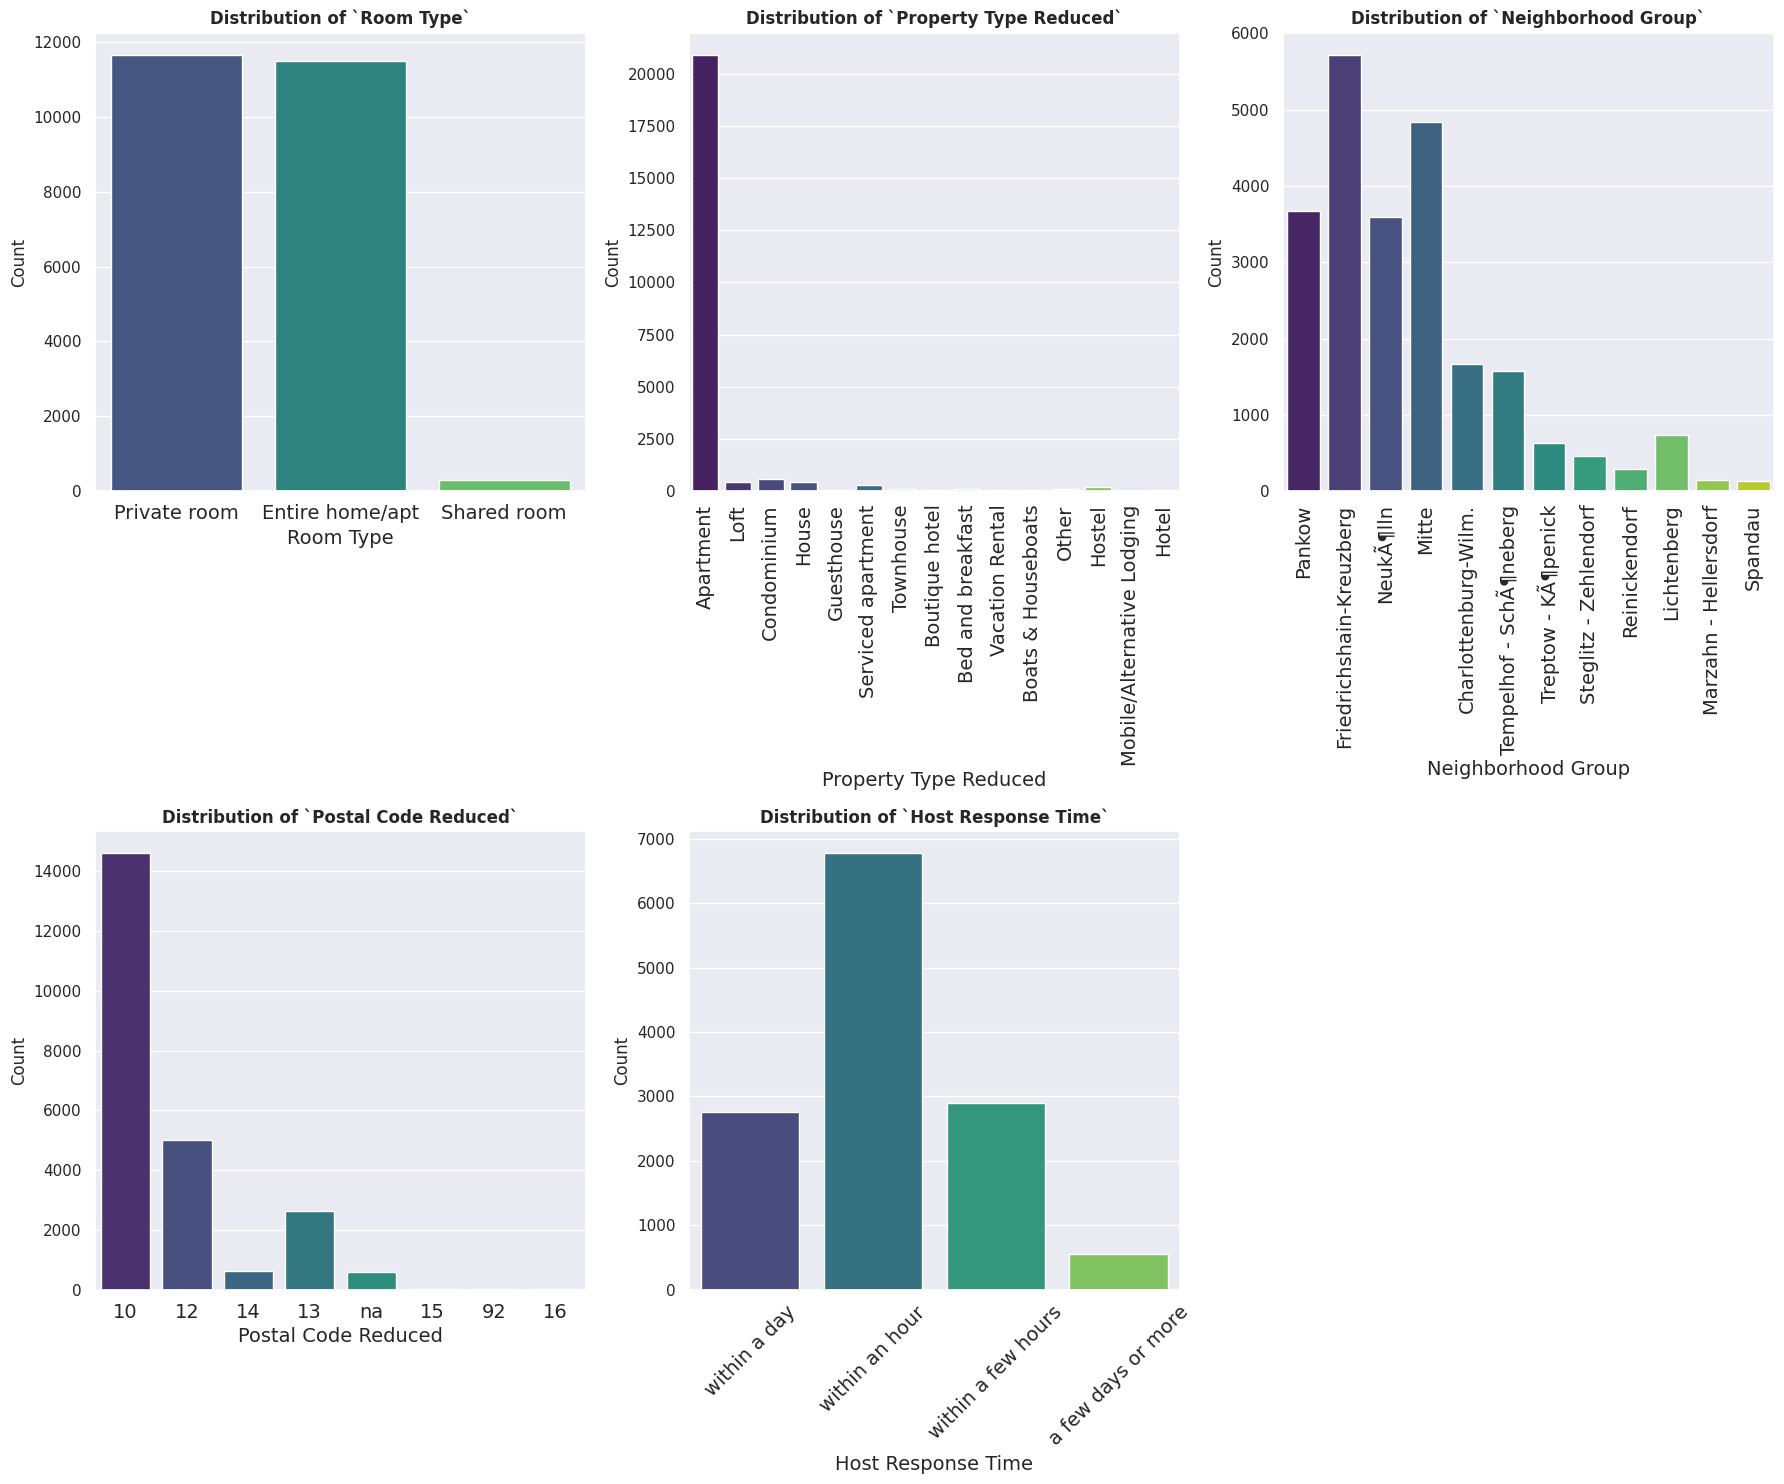

In [137]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Neighbourhood Grouped':90, 'Postal Code Reduced':0, 'Host Response Time':45}
i = 1
plt.figure(figsize=(18, 15))
plt.subplots_adjust(hspace = 0.5)
for col in categorical_columns:
  plt.subplot(2, 3, i)
  plt.title(f"Distribution of `{col}`", fontsize=12, fontweight="bold")
  plt.xlabel(col, fontsize=14)
  plt.xticks(rotation=xticks_map.get(col, 0), fontsize=14)
  plt.ylabel("Count")
  sns.countplot(data=df, x=col, palette="viridis")
  i = i + 1

plt.tight_layout()
plt.show()

## Continues and numrical data

### Histograms for continues numbers

Checking the distribution of key numerical features

In [144]:
numerical_columns

['Price',
 'Accomodates',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews']

In [145]:
def plot_histplot_for_columns(df, numerical_columns):
  plt.figure(figsize=(12, 12))
  plt.subplots_adjust(hspace = 0.5)
  for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col].dropna(), bins=50, kde=False)
    plt.title(f"Distribution of {col}")

  plt.tight_layout()
  plt.show()

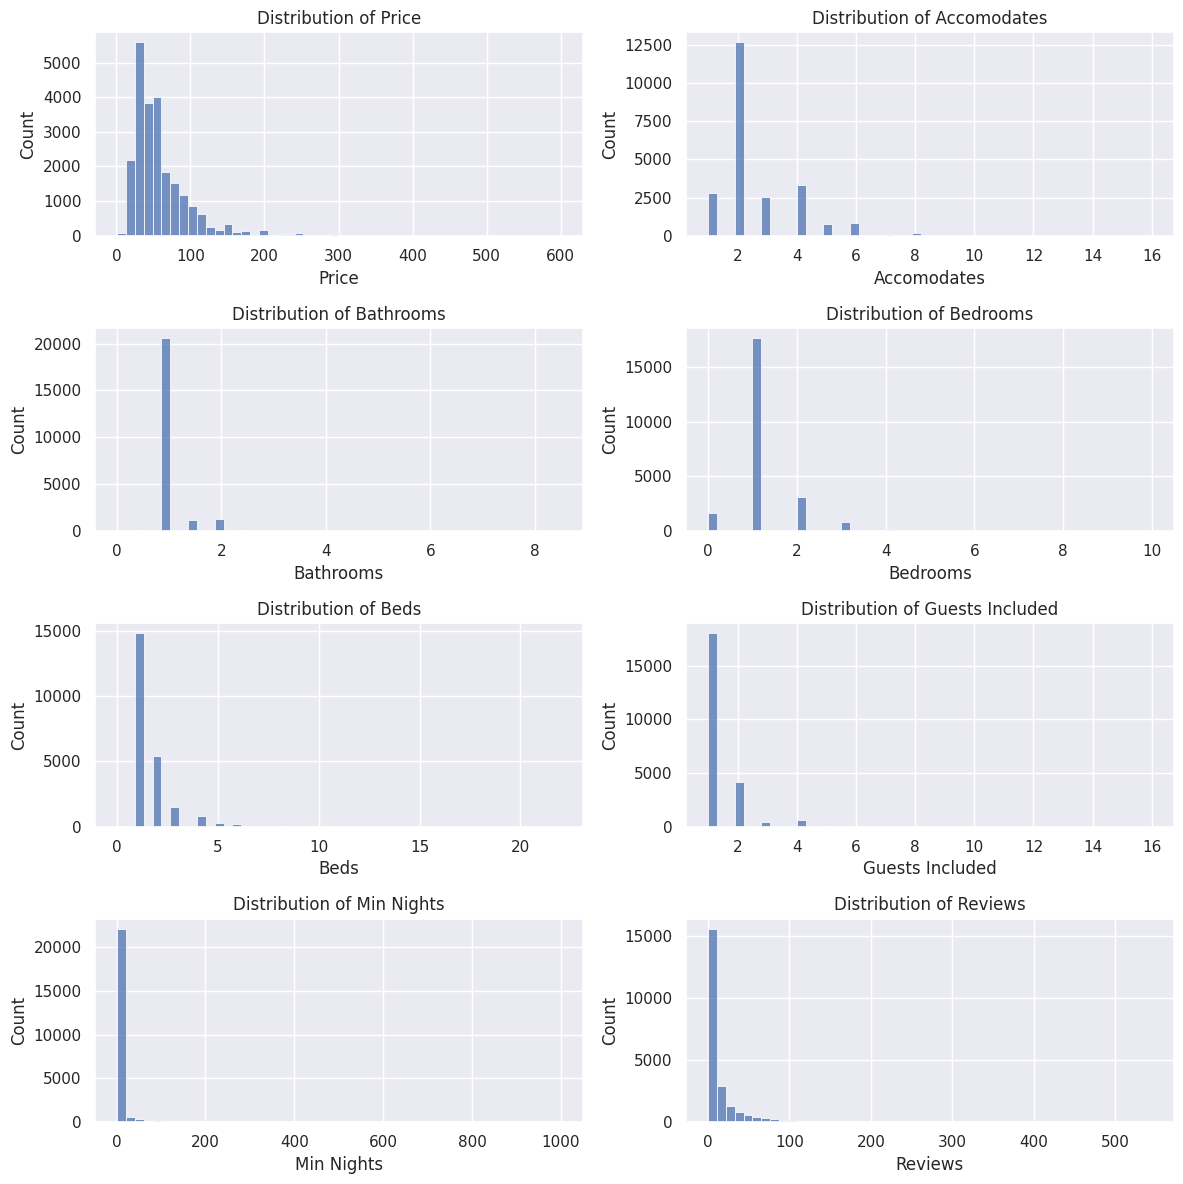

In [146]:
# Checking the distribution of key numerical features
plot_histplot_for_columns(df, numerical_columns)

As expected, we can notice that some of the numerics are more categorical data like (for example, Accomadates, Bathrooms and Beds).
It worth using barplot to show relations ship with target value

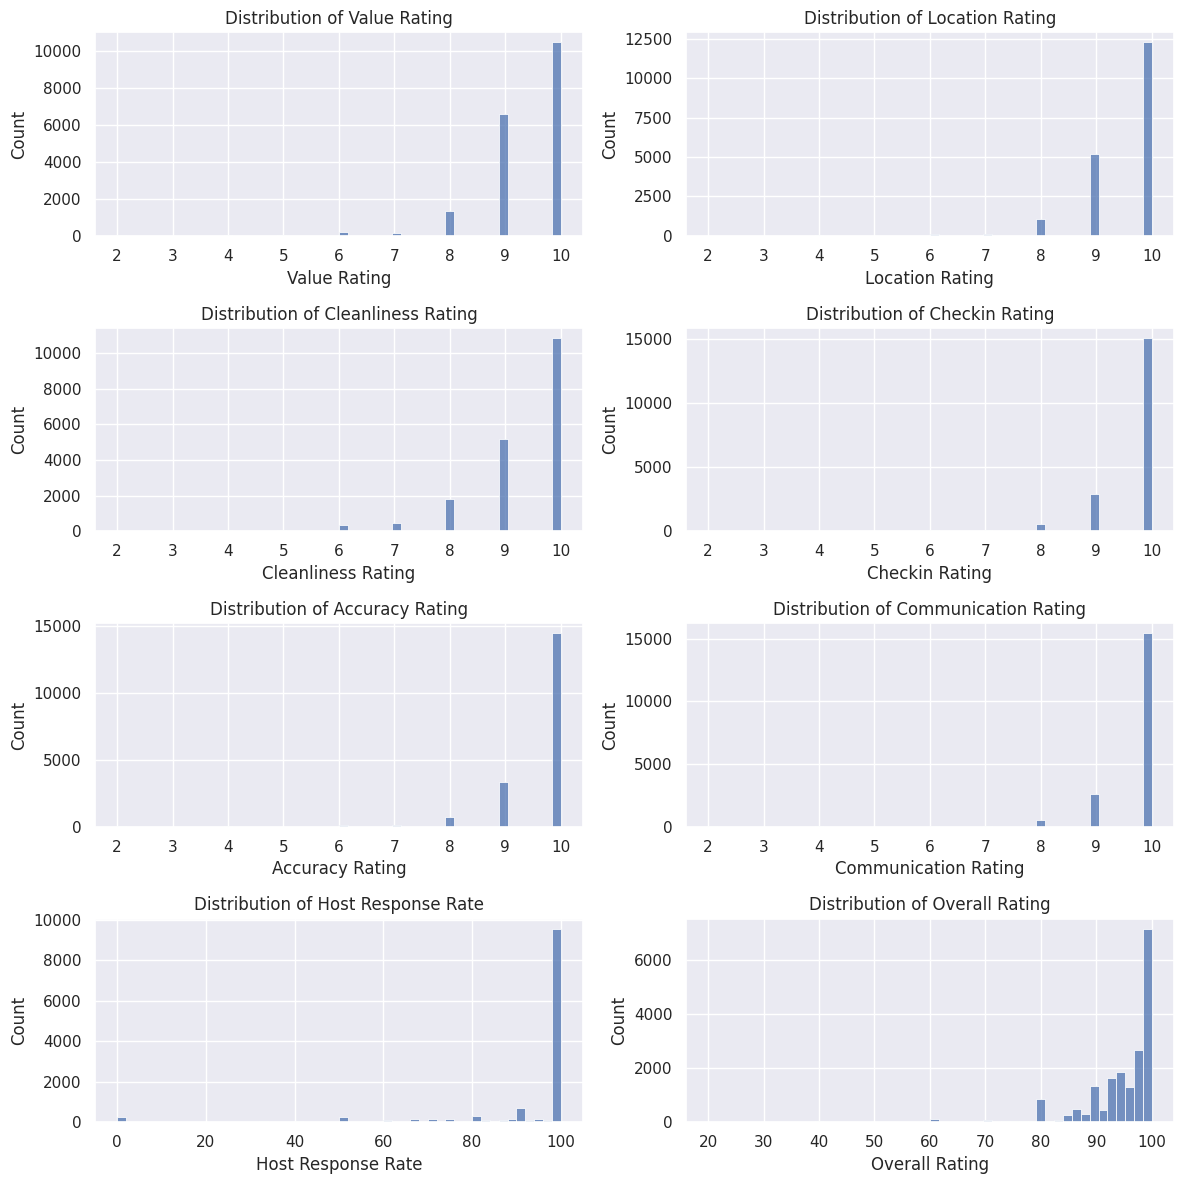

In [147]:
plot_histplot_for_columns(df, rating_columns)

### Bars for continues numbers

In [148]:
categorical_columns

['Room Type',
 'Property Type Reduced',
 'Neighborhood Group',
 'Postal Code Reduced',
 'Host Response Time']

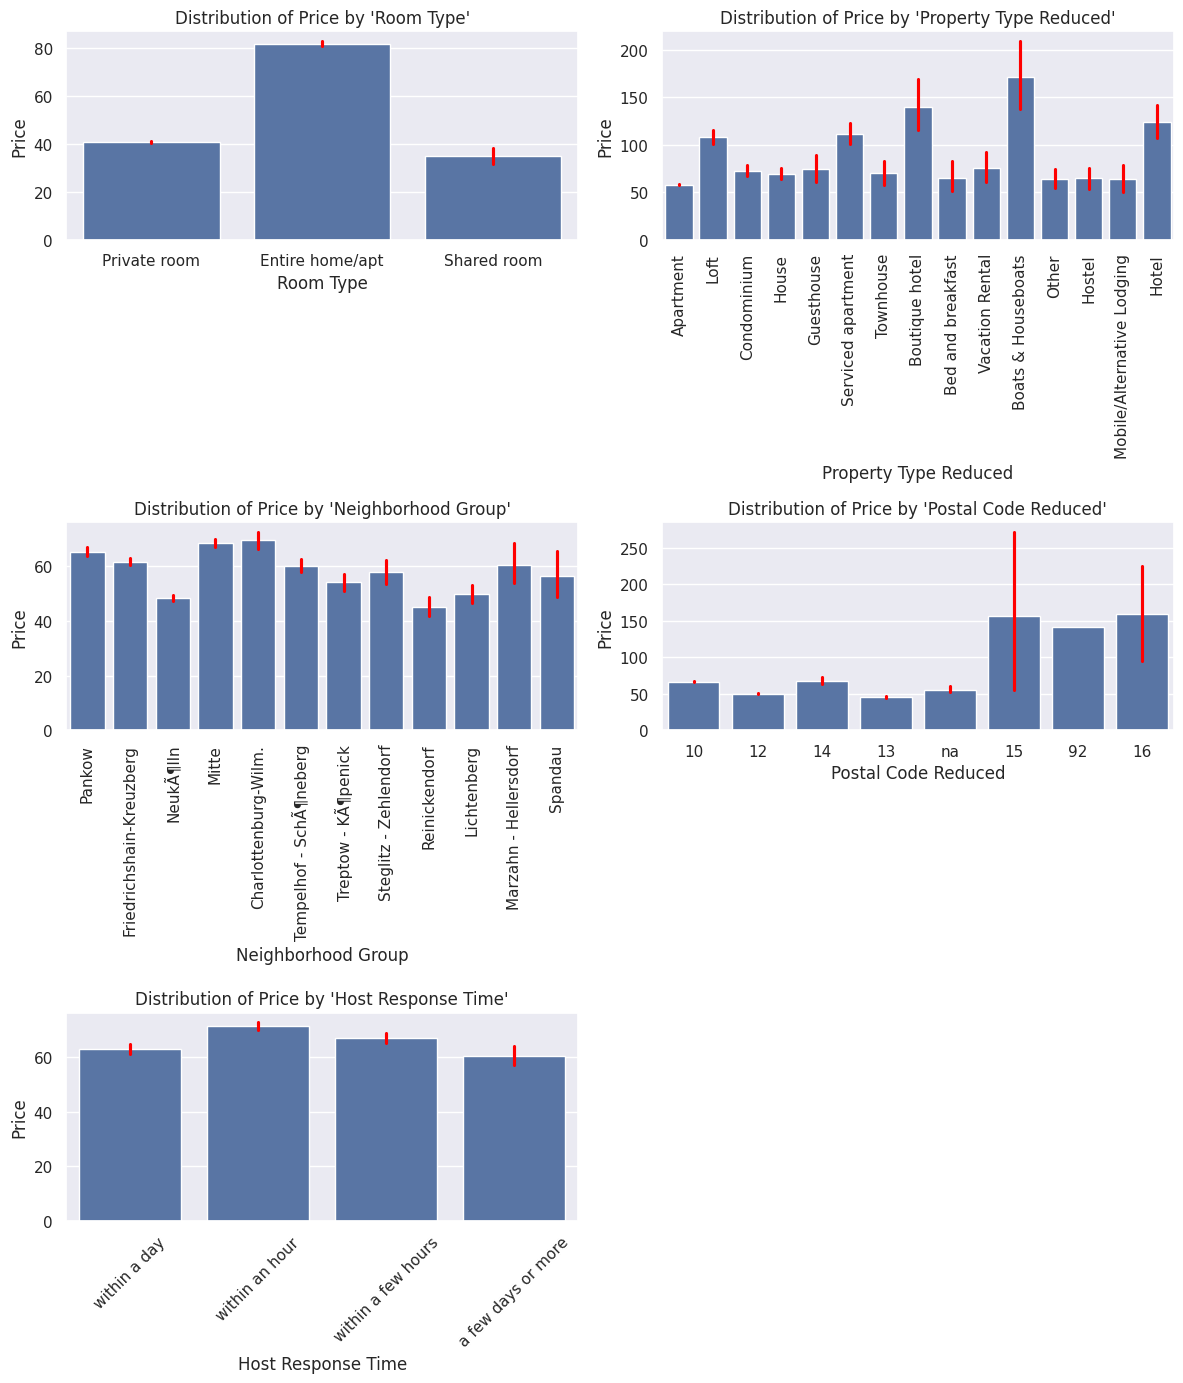

In [149]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Postal Code Reduced':0, 'Host Response Time':45}
plt.figure(figsize=(12, 14))
plt.subplots_adjust(hspace = 0.5)
for i, col in enumerate(categorical_columns, 1):
  plt.subplot(3, 2, i)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.xticks(rotation=xticks_map.get(col))
  plt.title(f"Distribution of Price by '{col}'")

plt.tight_layout()
plt.show()

check how the mean price varies for different neighborhoods, and how many outliers are present

<Axes: xlabel='Price', ylabel='Neighborhood Group'>

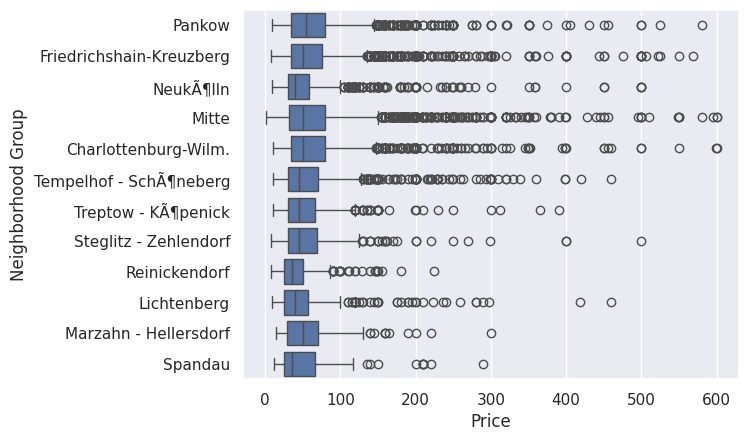

In [150]:
sns.boxplot(x=df['Price'],y=df['Neighborhood Group'],  orient='h')

In [151]:
df['Room Type'].value_counts()

,count
Room Type,
Private room,11658
Entire home/apt,11491
Shared room,311


<Axes: xlabel='Price', ylabel='Count'>

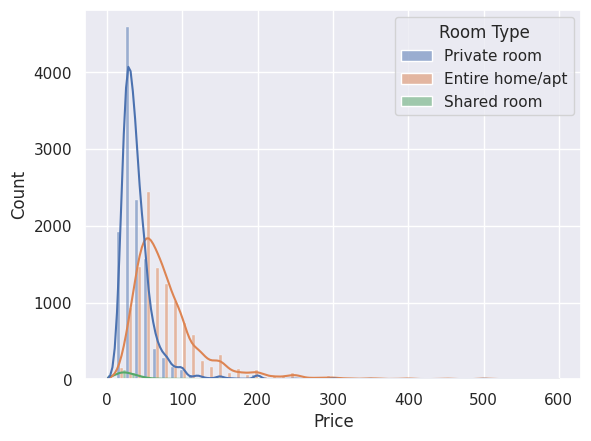

In [152]:
# sns.histplot(data = df[df['Room Type'] == 'Private room'], x="Price", bins=50, kde=True)
sns.histplot(data = df, x="Price", bins=50, hue="Room Type", kde=True, multiple="dodge")

<Axes: xlabel='Price', ylabel='Count'>

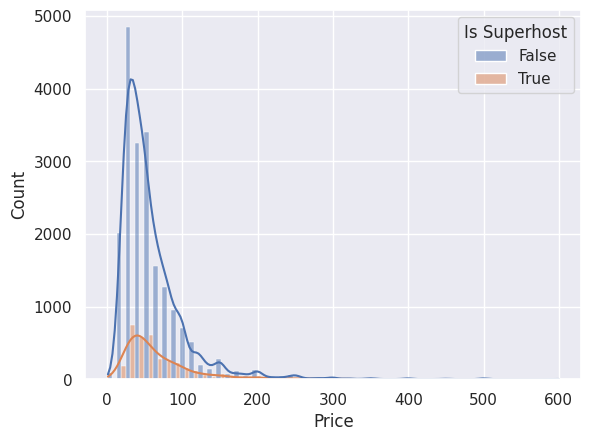

In [153]:
sns.histplot(data = df, x="Price", bins=50, hue="Is Superhost", kde=True, multiple="dodge")

<Axes: xlabel='Price', ylabel='Count'>

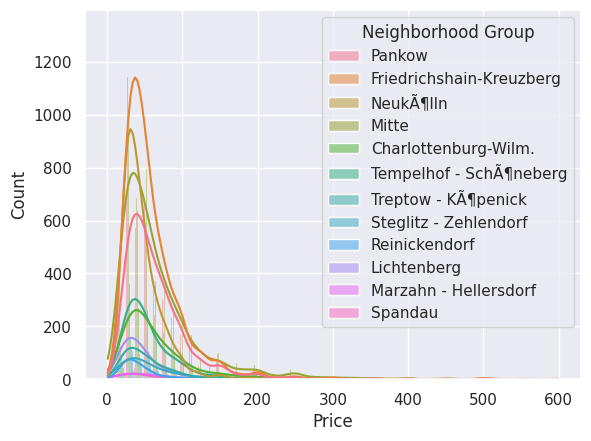

In [154]:
sns.histplot(data = df, x="Price", bins=50, hue="Neighborhood Group", kde=True, multiple="dodge")

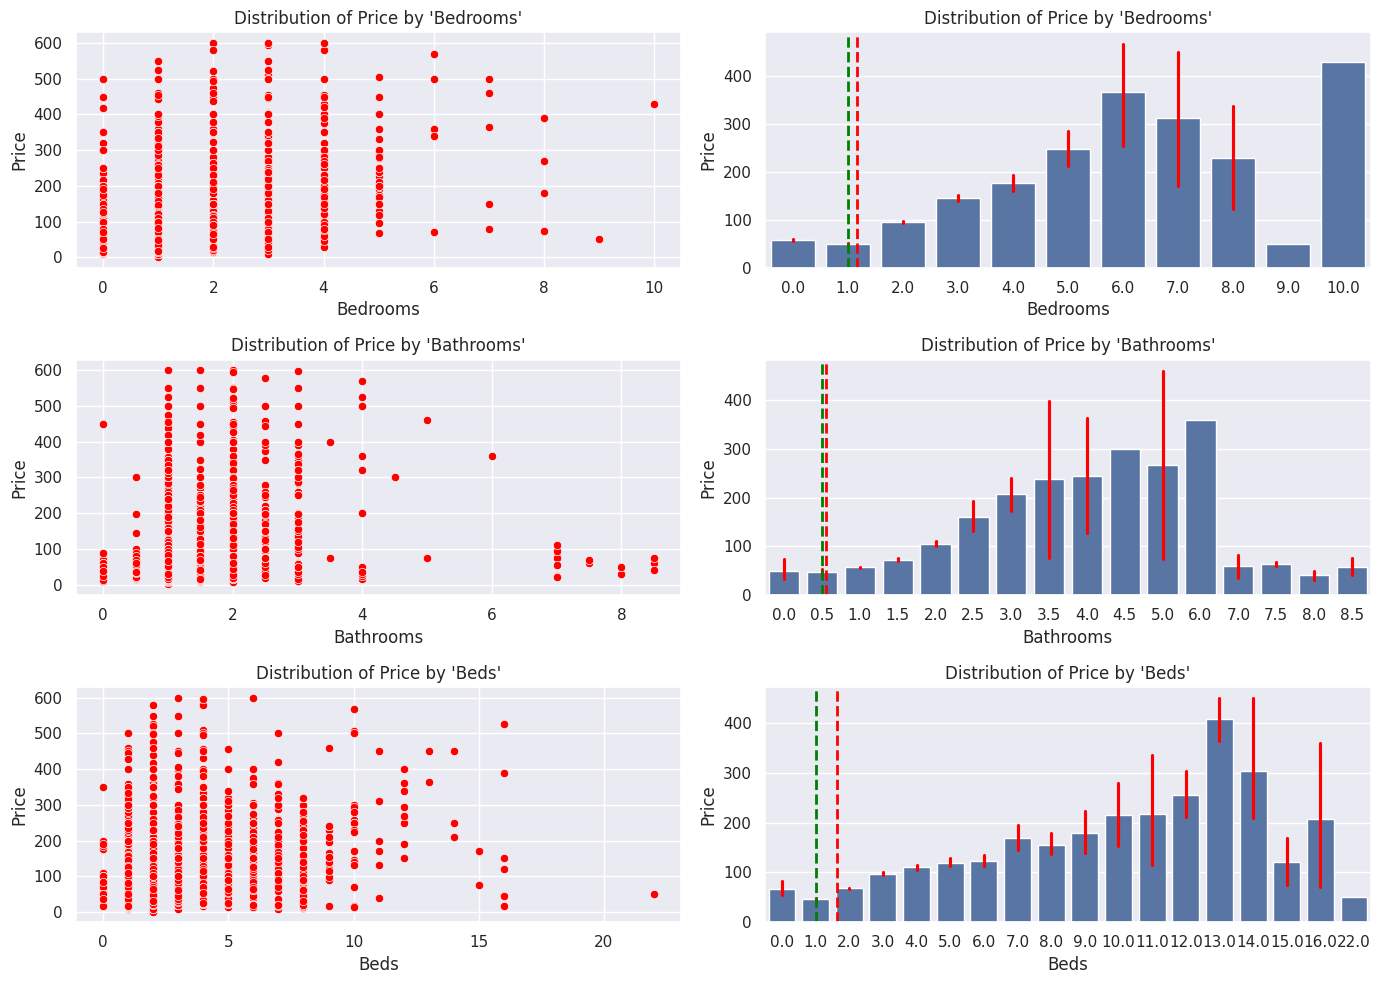

In [155]:
bar_plot_columns = ['Bedrooms', 'Bathrooms', 'Beds']
plt.figure(figsize=(14, 10))
plt.subplots_adjust(hspace = 0.5)
i = 1
for col in bar_plot_columns:
  plt.subplot(3, 2, i)
  sns.scatterplot(x=df[col], y=df['Price'], color='red')
  plt.title(f"Distribution of Price by '{col}'")

  plt.subplot(3, 2, i+1)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.title(f"Distribution of Price by '{col}'")
  plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2)
  plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2)

  i = i + 2
plt.tight_layout()
plt.show()

## Skewness

In [156]:
def highlight(cell_value):
    highlight = 'background-color: mediumspringgreen;'
    default = ''
    negative = 'background-color: hotpink;'
    if cell_value > 1:
        return highlight
    elif cell_value < -1:
        return negative
    #else
       # return default

numericals = numerical_columns + rating_columns
pd.DataFrame(df[numericals].skew(),columns=['skewness']).sort_values(by='skewness', ascending=False).style.applymap(highlight)

,skewness
Min Nights,21.506775
Bathrooms,6.738902
Guests Included,5.068270
Reviews,4.345326
Price,3.714219
Beds,3.598453
Accomodates,2.563539
Bedrooms,2.113660
Cleanliness Rating,-2.470840
Location Rating,-2.602092


## Checking correlations among numerical features

In [157]:
from sklearn.preprocessing import LabelEncoder

correlation_matrix_df = df.copy()
correlation_matrix_df['Host Since'] = pd.to_datetime(correlation_matrix_df['Host Since'])
correlation_matrix_df['Host Since Year'] = correlation_matrix_df['Host Since'].dt.year

# correlation_matrix_df = correlation_matrix_df.drop(columns=['Listing ID'], inplace=False)
correlation_matrix_df = correlation_matrix_df.select_dtypes(include=['number'])

le = LabelEncoder()
for col in categorical_columns:
  correlation_matrix_df[col] = le.fit_transform(df[col])

correlation_matrix = correlation_matrix_df.corr(method = 'spearman')
correlation_matrix

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Host Since Year,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
Accuracy Rating,1.000000,0.006310,0.421688,0.439086,0.452027,0.067496,-0.010288,0.277268,0.007996,0.504682,0.013267,-0.046632,0.466973,-0.068347,-0.015107,-0.094385,-0.019735,0.051160,0.020380,-0.014117,0.003075,-0.016254,0.023385,0.003656,-0.021792
Bathrooms,0.006310,1.000000,0.011782,0.006486,0.012124,0.025502,0.002502,0.019550,-0.038940,0.025882,0.134860,0.237171,0.006448,0.156795,0.246021,0.181533,0.090540,0.034927,0.003685,-0.015393,-0.007959,0.108463,-0.005159,-0.020376,-0.029129
Checkin Rating,0.421688,0.011782,1.000000,0.315407,0.530897,0.073366,-0.024226,0.233876,0.003390,0.383175,0.013840,0.003069,0.346310,-0.040509,0.000829,-0.045640,-0.008495,0.017417,0.006039,-0.006588,0.020630,0.016520,0.023201,0.021725,-0.022635
Cleanliness Rating,0.439086,0.006486,0.315407,1.000000,0.336250,0.104863,0.005036,0.217219,-0.012711,0.536756,0.109701,-0.002138,0.414862,-0.025764,0.024164,-0.029026,0.019746,0.012808,0.030925,-0.019725,-0.044139,0.048289,0.033427,-0.006598,-0.061873
Communication Rating,0.452027,0.012124,0.530897,0.336250,1.000000,0.103405,-0.019167,0.254591,0.005967,0.428698,0.024043,-0.048749,0.370536,-0.046071,0.000601,-0.062302,-0.008040,0.032425,0.005321,-0.029663,0.003264,-0.012157,0.021511,0.011635,-0.025161
Host Response Rate,0.067496,0.025502,0.073366,0.104863,0.103405,1.000000,0.002746,0.011694,-0.009776,0.060043,0.057301,-0.055334,0.047651,0.049720,0.035641,0.039136,0.063555,0.003731,0.126683,-0.021736,-0.012031,0.034354,0.014514,0.001600,0.481177
Latitude,-0.010288,0.002502,-0.024226,0.005036,-0.019167,0.002746,1.000000,0.002605,-0.150673,-0.035905,0.057407,-0.009606,-0.028445,0.040085,0.004600,0.028584,0.028408,-0.006008,0.039117,0.021866,-0.040273,0.007495,-0.024051,-0.115806,-0.017635
Location Rating,0.277268,0.019550,0.233876,0.217219,0.254591,0.011694,0.002605,1.000000,-0.009025,0.312819,0.107509,0.109152,0.316271,-0.051158,-0.020243,-0.071736,-0.034317,0.031919,-0.012515,-0.013121,-0.008191,-0.050379,-0.080322,-0.232805,-0.067337
Longitude,0.007996,-0.038940,0.003390,-0.012711,0.005967,-0.009776,-0.150673,-0.009025,1.000000,0.031048,-0.051213,-0.160150,0.027583,-0.018343,-0.010791,-0.036266,0.003868,-0.012872,-0.031048,-0.044229,0.035672,-0.015465,-0.022955,-0.076449,0.050897
Overall Rating,0.504682,0.025882,0.383175,0.536756,0.428698,0.060043,-0.035905,0.312819,0.031048,1.000000,0.019370,0.041631,0.561760,-0.089425,0.002468,-0.096480,-0.065424,0.083997,-0.272095,0.022734,0.017814,-0.017532,0.018470,0.008010,0.031741


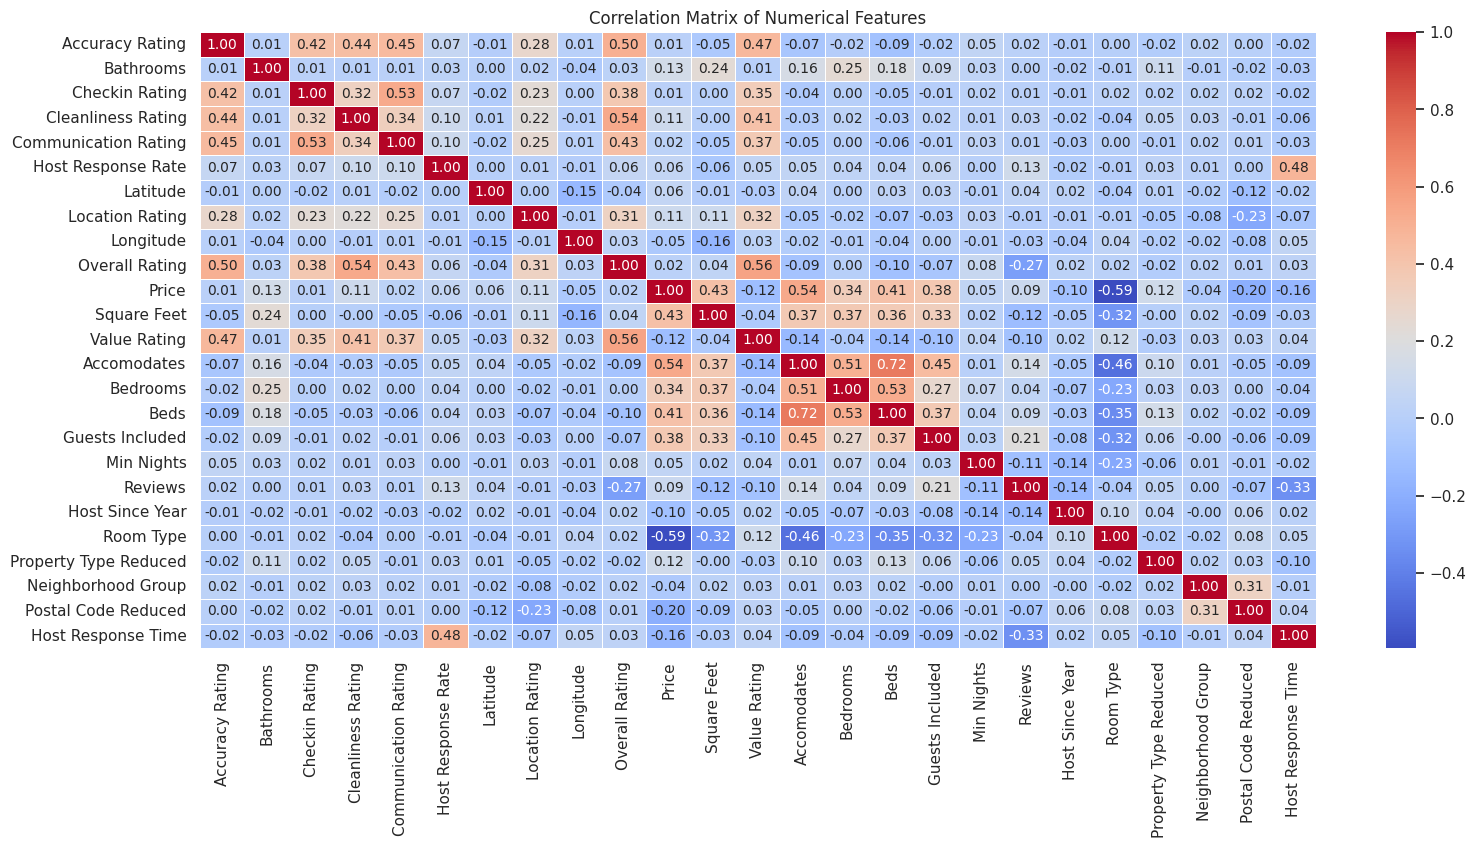

In [158]:
plt.figure(figsize=(18, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 10})
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [159]:
df = df.drop(columns=['review_date'])

## Outliers

In [160]:
nonn_dummy = numerical_columns + rating_columns
df[nonn_dummy].describe().loc[['min', '25%', '50%', '75%', 'max']].T

,min,25%,50%,75%,max
Price,1.0,31.0,49.0,74.0,600.0
Accomodates,1.0,2.0,2.0,3.0,16.0
Bathrooms,0.0,1.0,1.0,1.0,8.5
Bedrooms,0.0,1.0,1.0,1.0,10.0
Beds,0.0,1.0,1.0,2.0,22.0
Guests Included,1.0,1.0,1.0,1.0,16.0
Min Nights,1.0,2.0,3.0,4.0,1000.0
Reviews,0.0,1.0,5.0,17.0,545.0
Value Rating,2.0,9.0,10.0,10.0,10.0
Location Rating,2.0,9.0,10.0,10.0,10.0


In [161]:
df_num = df._get_numeric_data().dropna()
df_num_non_dummy = df_num.drop(columns=boolean_columns)
num_non_dummy_columns = df_num_non_dummy.columns
df_num_non_dummy.shape
num_non_dummy_columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'Accomodates', 'Bedrooms', 'Beds',
       'Guests Included', 'Min Nights', 'Reviews'],
      dtype='object')

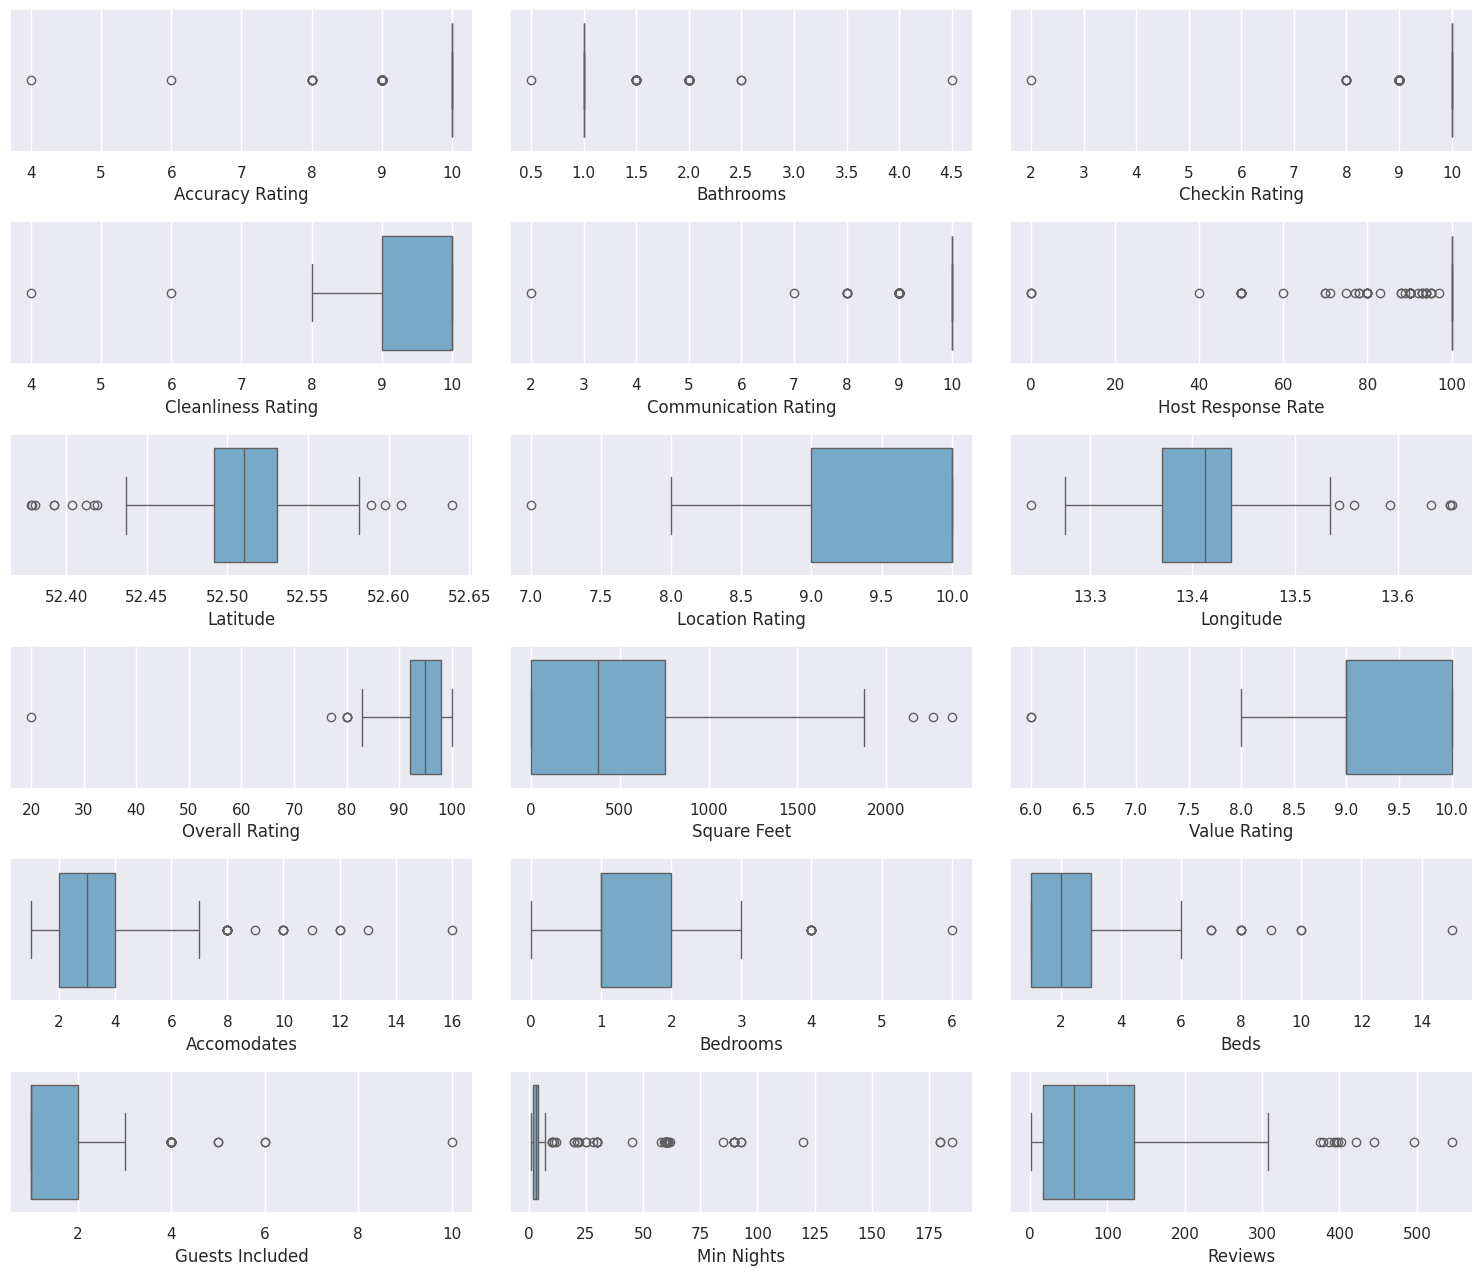

In [162]:
def outlier_boxplot(df):
  plt.figure(figsize=(15, 40))
  j = 1
  r = len(df.columns)
  for i, col in enumerate([c for c in df if c != 'Price'], 1):
    plt.subplot(r, 3, i)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.subplots_adjust(hspace = 0.6)

  plt.tight_layout()
  plt.show()

outlier_boxplot(df_num_non_dummy)

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Likely contains extreme values (high-end listings or pricing errors).
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [163]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in df_num_non_dummy:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  return pd.DataFrame({
      'min': min_vals,
      'max': max_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=num_non_dummy_columns)

df_describe(df_num_non_dummy, num_non_dummy_columns)

,min,max,Q1(25%),Q2(50%),Q3(75%),IQR,lower_bound,upper_bound
Accuracy Rating,4.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Bathrooms,0.50000,4.50000,1.00000,1.00000,1.00000,0.00000,1.000000,1.000000
Checkin Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Cleanliness Rating,4.00000,10.00000,9.00000,10.00000,10.00000,1.00000,7.500000,11.500000
Communication Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Host Response Rate,0.00000,100.00000,100.00000,100.00000,100.00000,0.00000,100.000000,100.000000
Latitude,52.37828,52.63913,52.49150,52.51037,52.53055,0.03905,52.432925,52.589125
Location Rating,7.00000,10.00000,9.00000,10.00000,10.00000,1.00000,7.500000,11.500000
Longitude,13.24245,13.65275,13.37033,13.41194,13.43787,0.06754,13.269020,13.539180
Overall Rating,20.00000,100.00000,92.00000,95.00000,98.00000,6.00000,83.000000,107.000000


# Data Cleansing

## outliers

### outliers_df

Based on previous histograms and skewness visualizations, we can observe that the data is not normally distributed. To identify outliers, we will apply the IQR method, establishing boundaries before Q1 and after Q3. Any values falling outside these boundaries will be considered outliers.

In [164]:
def count_outliers_df(df):
    total_outliers = pd.DataFrame(columns=['Outlier count', 'Percent'])
    # for col in df:  # Ensure processing numeric columns only
    for col in [c for c in df if c != 'Price']:  # Ensure processing numeric columns only and exclude Price
        temp = pd.DataFrame(df[col])
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        # Filter rows that are outliers in either direction
        temp_outliers = temp[(temp[col] > upper_limit) | (temp[col] < lower_limit)]
        num_outliers = len(temp_outliers)
        total_outliers.loc[col] = [num_outliers, num_outliers / len(df) * 100]

    return total_outliers[total_outliers['Percent'] > 0]

In [165]:
# Assume df_num_non_dummy is your DataFrame
# Call the function and sort results
outliers_df = count_outliers_df(df_num_non_dummy).sort_values('Percent', ascending=False)
outliers_df, outliers_df.shape

(                      Outlier count    Percent
 Accuracy Rating                74.0  24.915825
 Checkin Rating                 60.0  20.202020
 Host Response Rate             56.0  18.855219
 Min Nights                     53.0  17.845118
 Bathrooms                      52.0  17.508418
 Communication Rating           51.0  17.171717
 Guests Included                26.0   8.754209
 Accomodates                    20.0   6.734007
 Latitude                       13.0   4.377104
 Reviews                        11.0   3.703704
 Beds                           10.0   3.367003
 Bedrooms                        9.0   3.030303
 Longitude                       8.0   2.693603
 Overall Rating                  5.0   1.683502
 Square Feet                     3.0   1.010101
 Cleanliness Rating              2.0   0.673401
 Value Rating                    2.0   0.673401
 Location Rating                 1.0   0.336700,
 (18, 2))

In [166]:
outliers_df.to_csv('/content/drive/My Drive/Airbnb/outliers_df.csv')

### new_df_outliers - labeling with 'Outlier'
Labeling every outlier with 'Outlier'

In [167]:
def outliers(df):
    label_out_df = df.copy()
    for col in label_out_df:
        if col in outliers_df.index:
            Q1 = label_out_df[col].quantile(0.25)
            Q3 = label_out_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            label_out_df[col] = np.where(label_out_df[col] > upper_limit, 'Outlier',
                                         np.where(label_out_df[col] < lower_limit,
                                                  'Outlier', label_out_df[col]))
    return label_out_df

new_df_outliers = outliers(df)
new_df_outliers.drop(columns=['Comments'], inplace=False).head(5)

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,10.0,1.0,10.0,10.0,10.0,Outlier,52.54851,9.0,13.40455,100.0,17.0,nan,10.0,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2,1.0,1.0,1,2,7,Apartment,10
1,Outlier,1.0,Outlier,9.0,Outlier,Outlier,52.535,10.0,13.41758,92.0,90.0,720.0,9.0,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4,1.0,2.0,Outlier,Outlier,Outlier,Apartment,10
2,10.0,1.0,10.0,10.0,10.0,100.0,52.54316,10.0,13.41509,96.0,33.0,nan,10.0,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2,1.0,2.0,1,2,Outlier,Apartment,10
3,10.0,Outlier,10.0,10.0,10.0,100.0,52.53303,10.0,13.41605,100.0,180.0,nan,10.0,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Outlier,Outlier,Outlier,Outlier,6,6,Apartment,10
4,10.0,1.0,Outlier,10.0,10.0,100.0,52.54785,9.0,13.40556,93.0,70.0,nan,9.0,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,1,Outlier,1.0,1,Outlier,23,Apartment,10


### df_outliers - 0/1

Creating a dataframe with outliers as 1 and non-outliers as 0:

In [168]:
df_outliers = new_df_outliers.isin(['Outlier'])
df_outliers = df_outliers.astype('int')
df_outliers

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
23532,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
23533,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23534,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0


Now that we have a dataframe saving all the outliers we'll convert all the outliers to nulls, just so I can see differences in distribution with and without outliers and then decide which of the outliers to remove or not:

In [169]:
def capping(df):
    temp = df.copy()
    for col in temp:
        if col in outliers_df.index:
            Q1 = temp[col].quantile(0.25)
            Q3 = temp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            temp[col] = np.where(temp[col] > upper_limit,np.nan,np.where(temp[col] < lower_limit,np.nan,temp[col]))
    return temp
temp = capping(df)
temp.drop(columns=['Comments'], inplace=False).head()


,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,10.0,1.0,10.0,10.0,10.0,NaN,52.54851,9.0,13.40455,100.0,17.0,NaN,10.0,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2.0,1.0,1.0,1.0,2.0,7.0,Apartment,10
1,NaN,1.0,NaN,9.0,NaN,NaN,52.53500,10.0,13.41758,92.0,90.0,720.0,9.0,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4.0,1.0,2.0,NaN,NaN,NaN,Apartment,10
2,10.0,1.0,10.0,10.0,10.0,100.0,52.54316,10.0,13.41509,96.0,33.0,NaN,10.0,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2.0,1.0,2.0,1.0,2.0,NaN,Apartment,10
3,10.0,NaN,10.0,10.0,10.0,100.0,52.53303,10.0,13.41605,100.0,180.0,NaN,10.0,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,NaN,NaN,NaN,NaN,6.0,6.0,Apartment,10
4,10.0,1.0,NaN,10.0,10.0,100.0,52.54785,9.0,13.40556,93.0,70.0,NaN,9.0,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,1.0,NaN,1.0,1.0,NaN,23.0,Apartment,10


In [170]:
temp.to_csv('/content/drive/My Drive/Airbnb/outliers_q_df.csv')

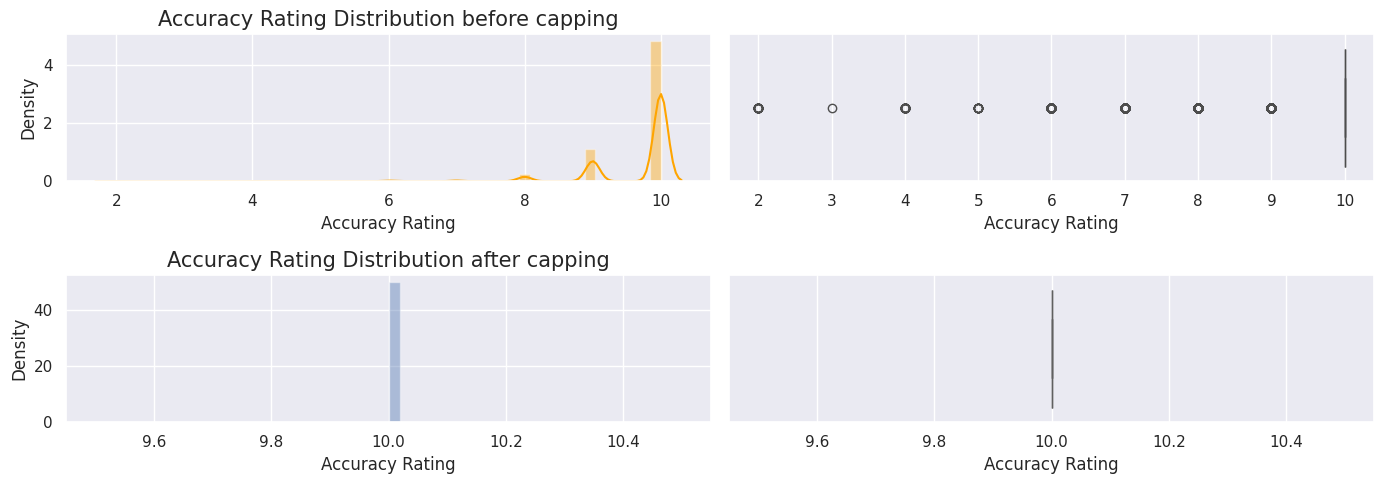

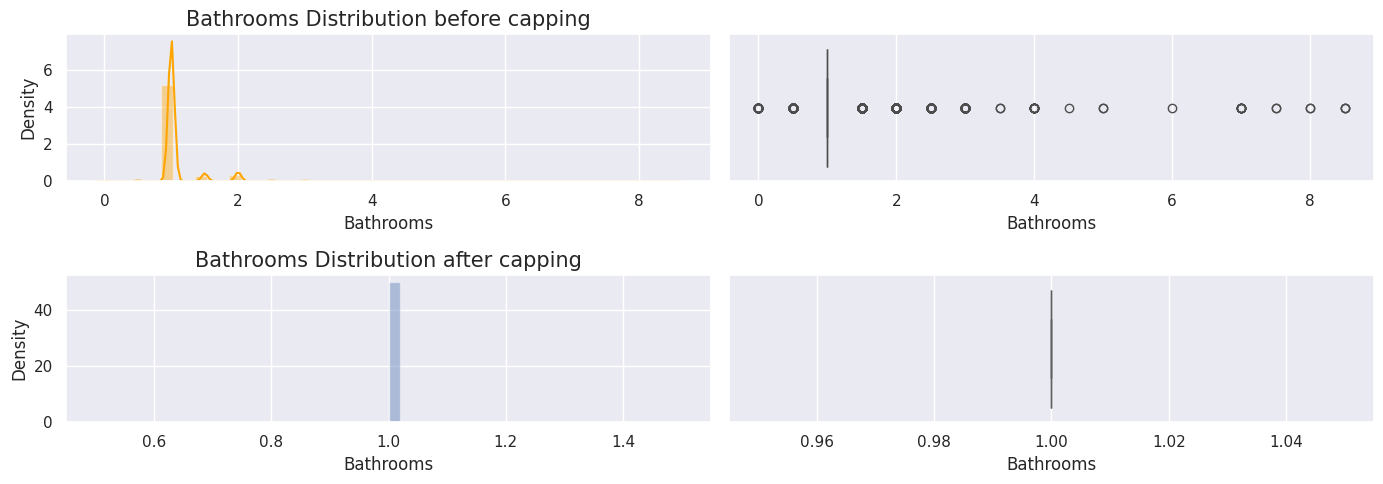

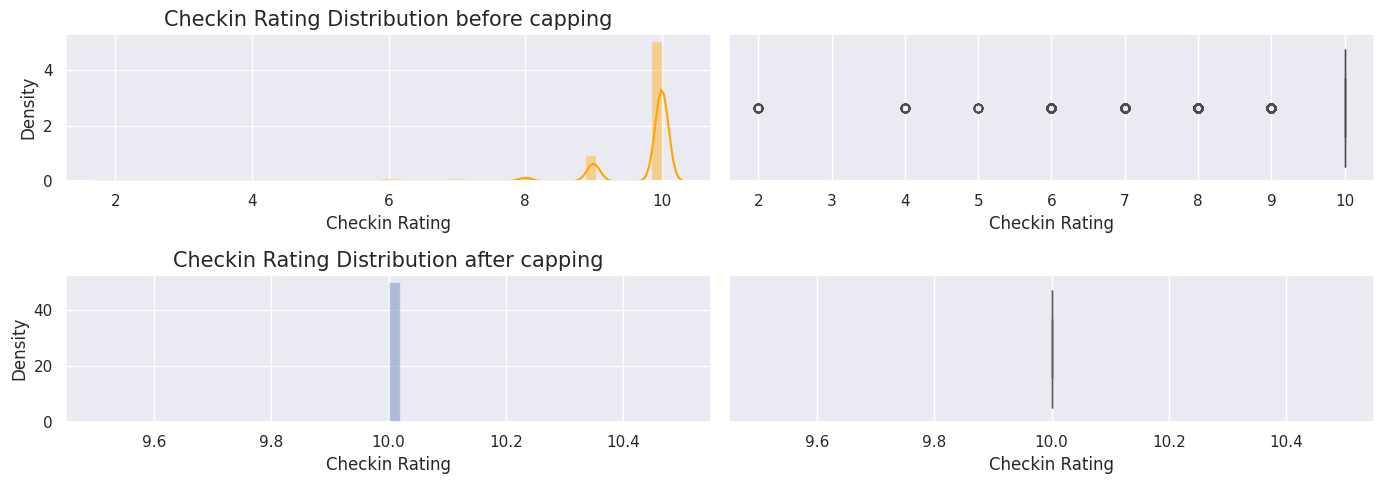

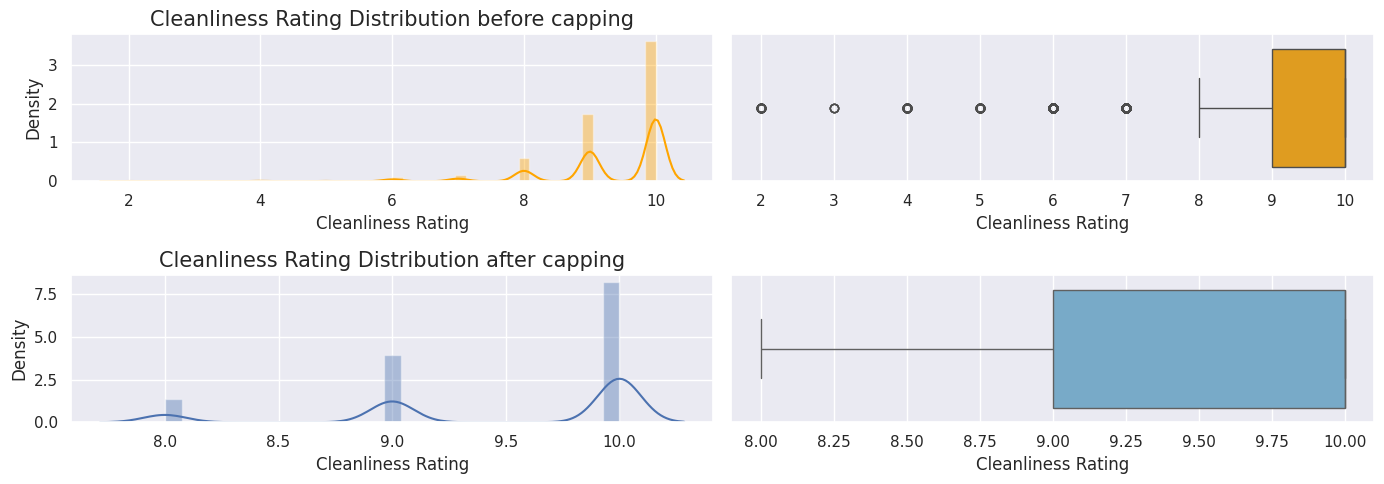

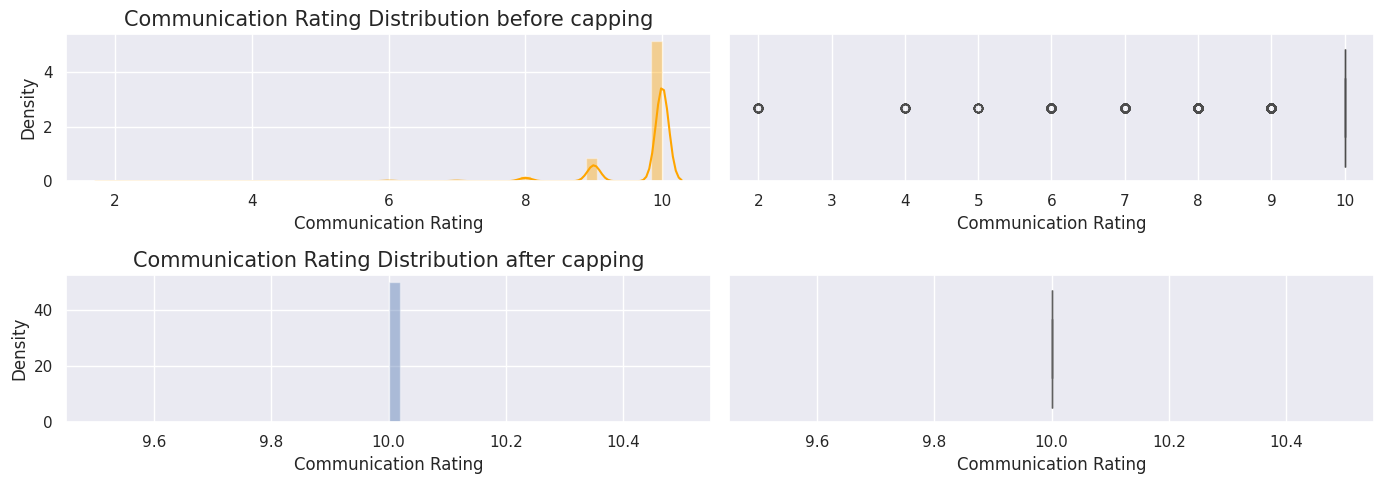

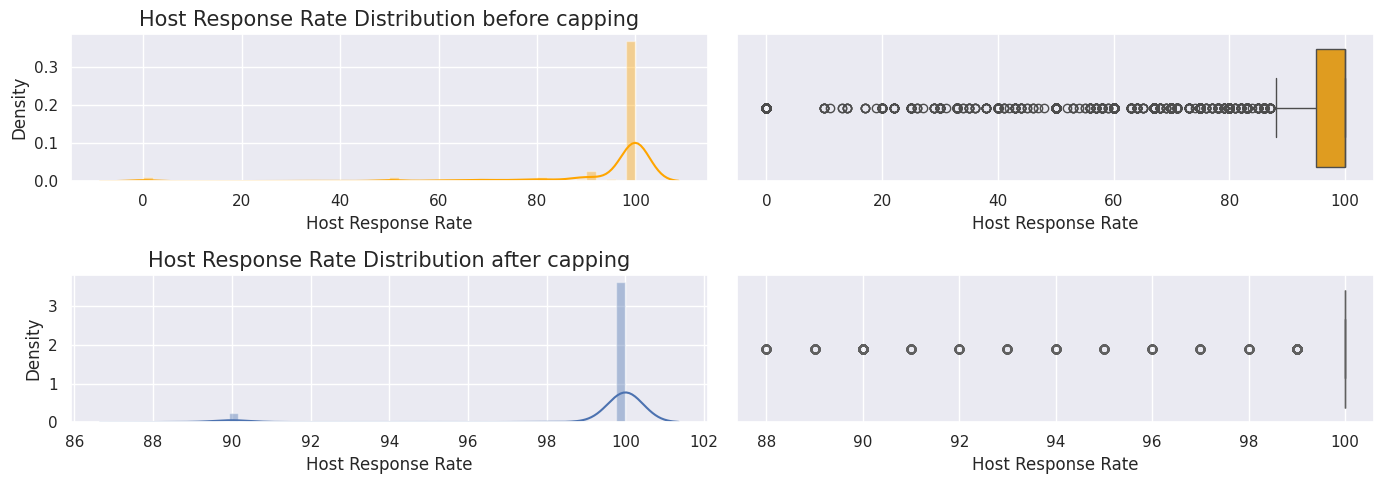

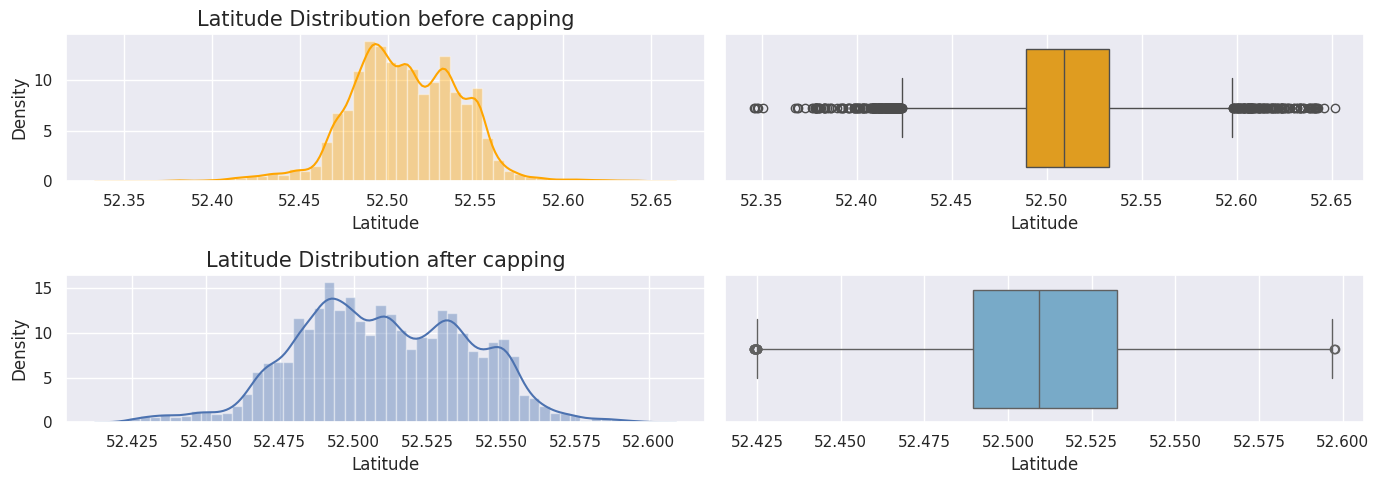

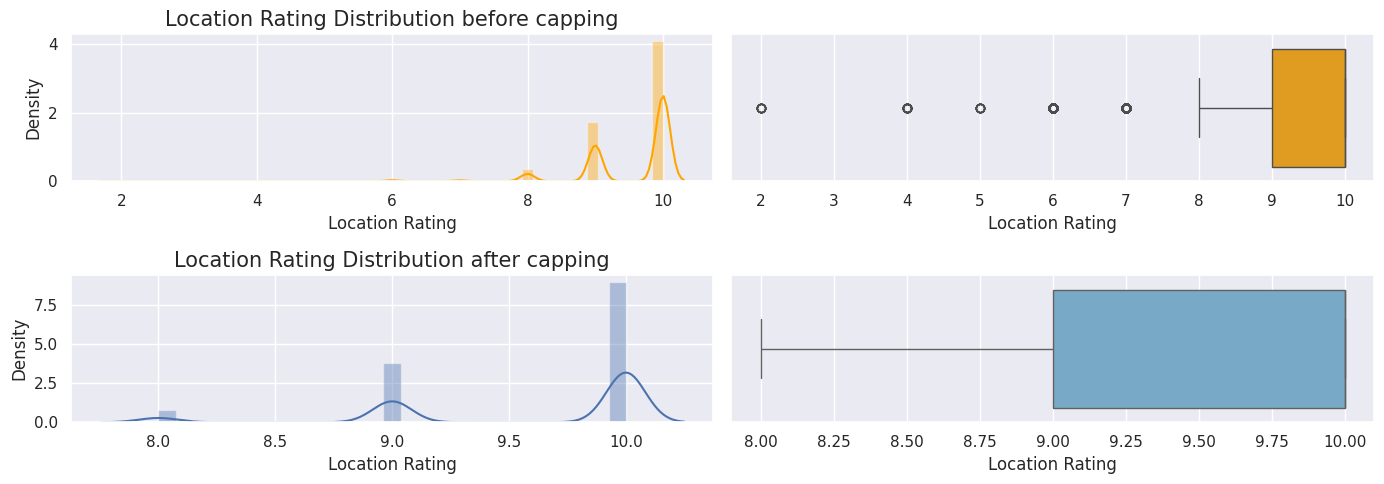

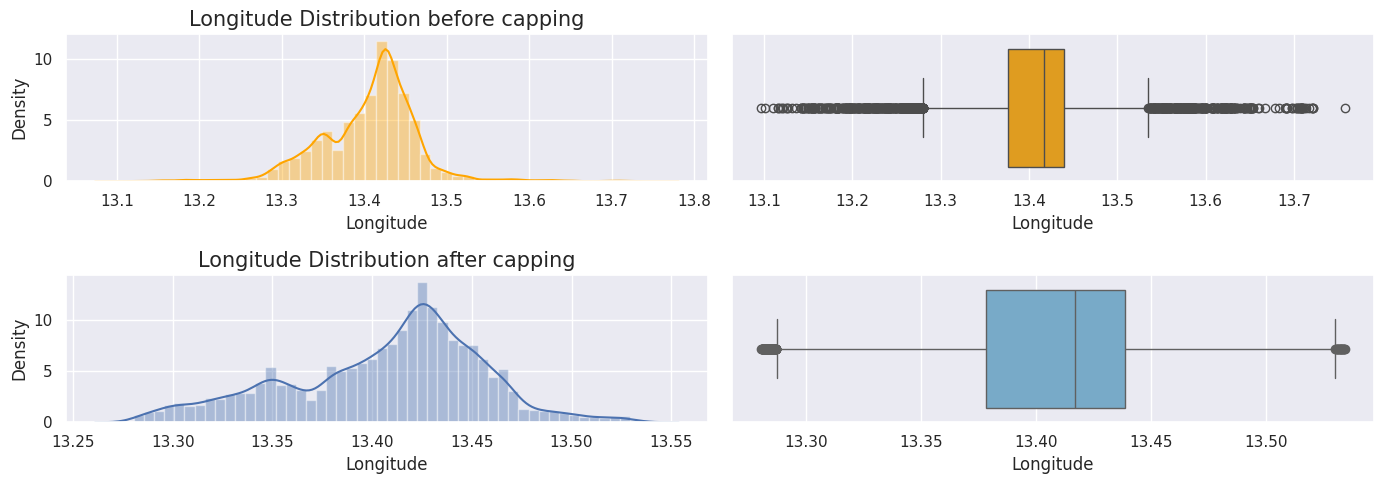

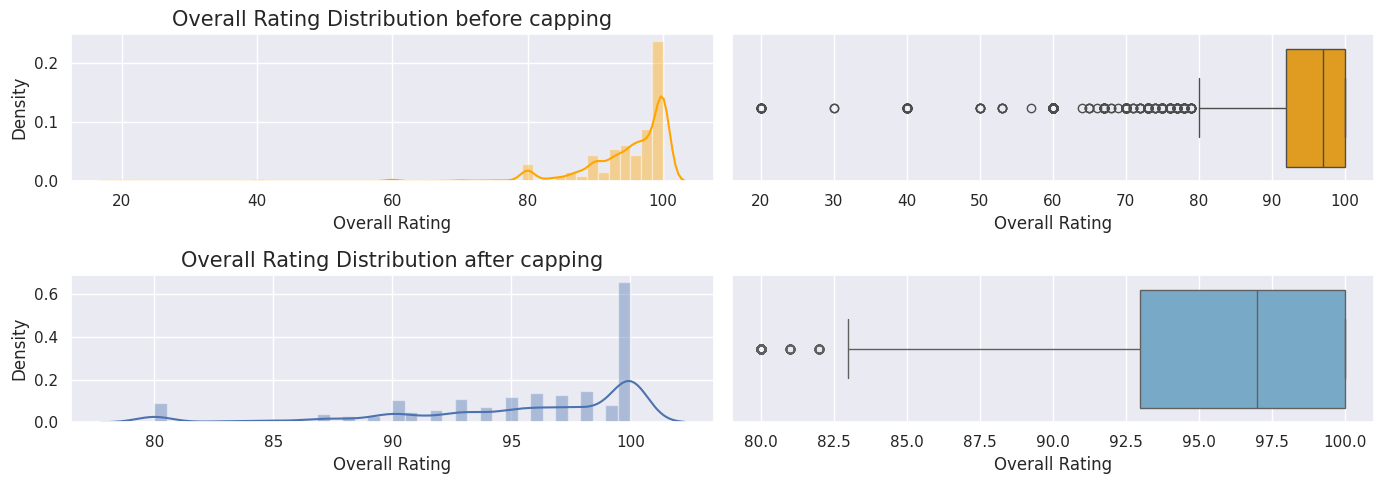

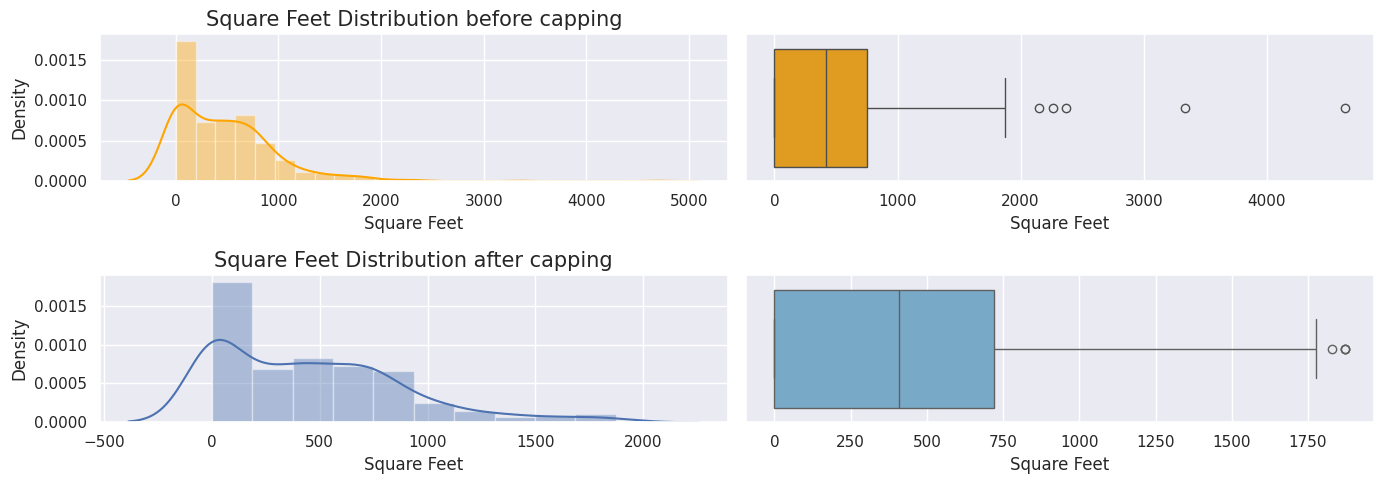

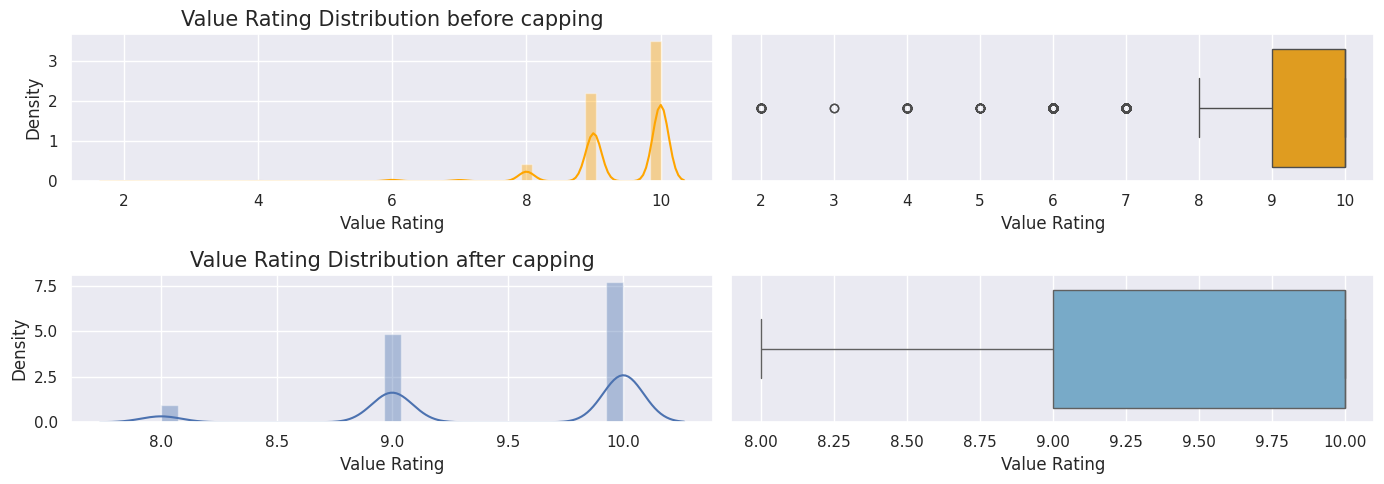

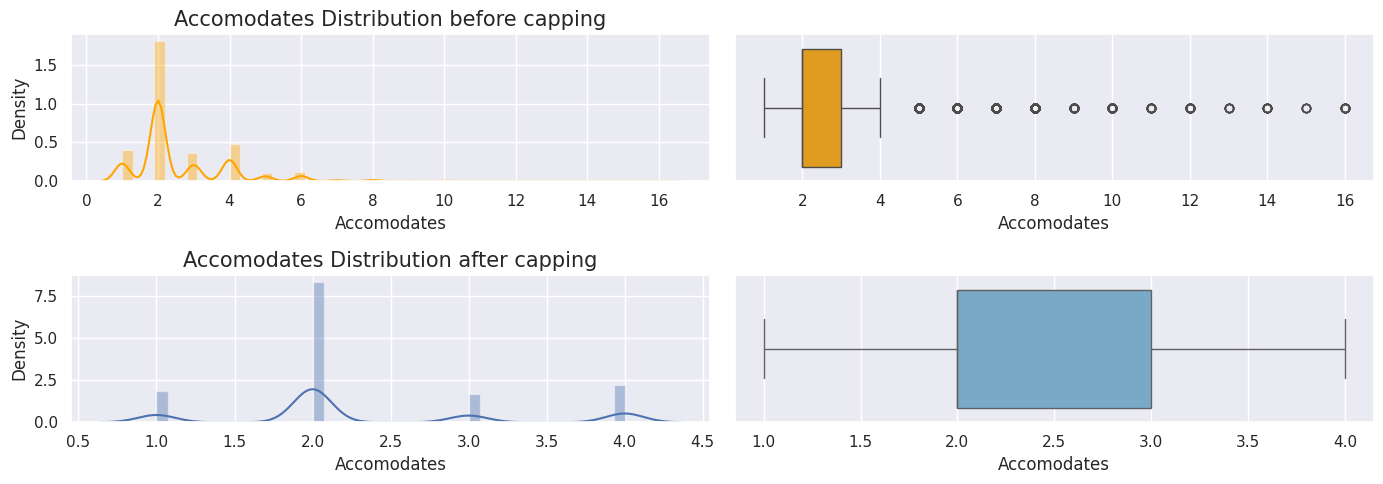

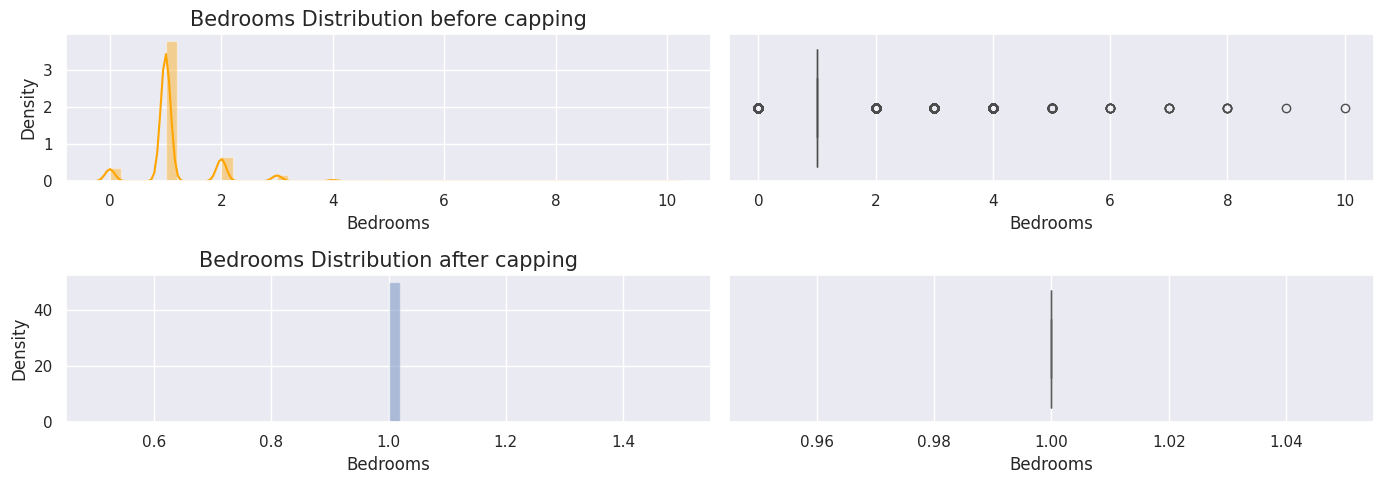

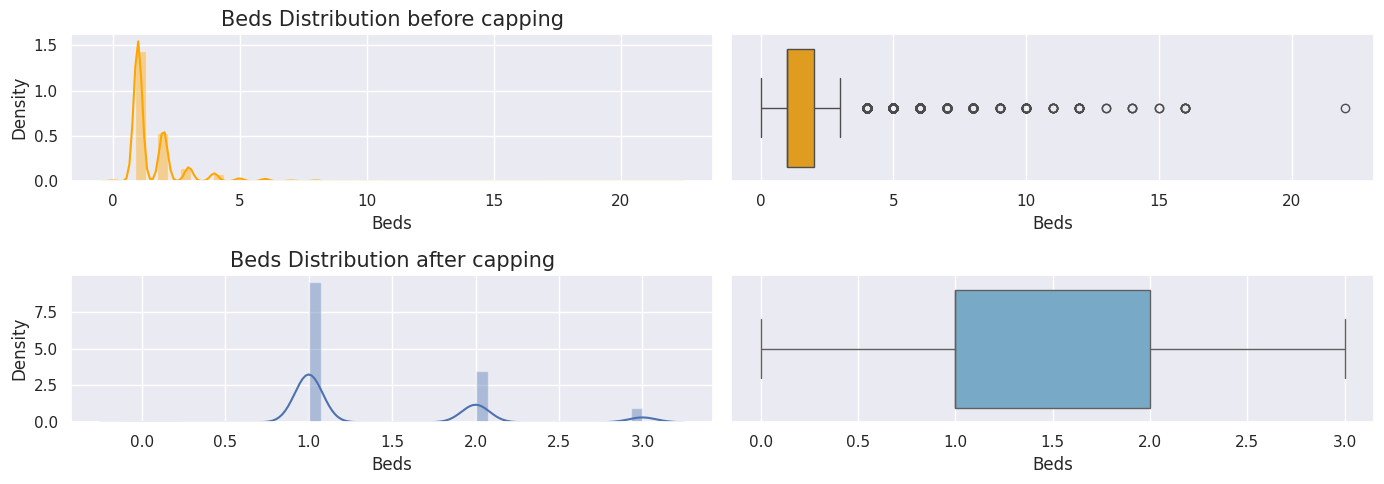

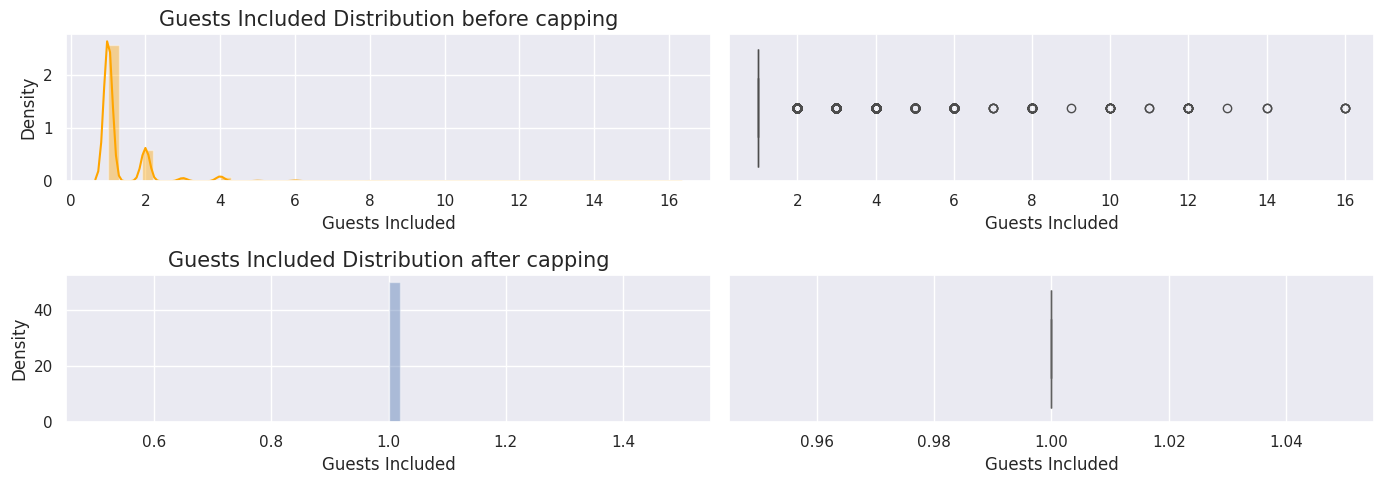

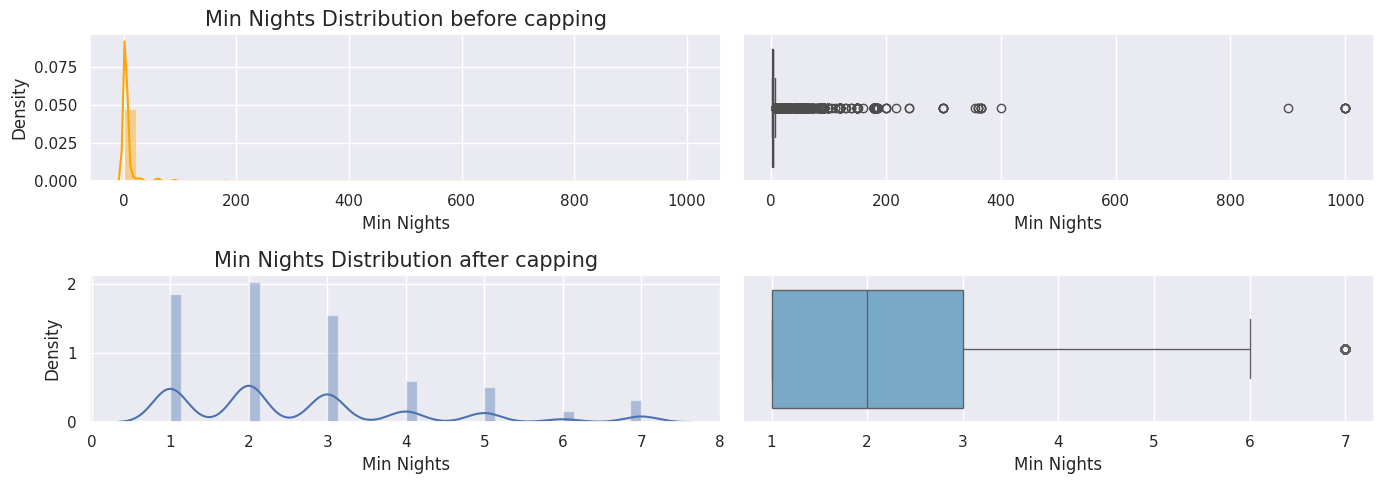

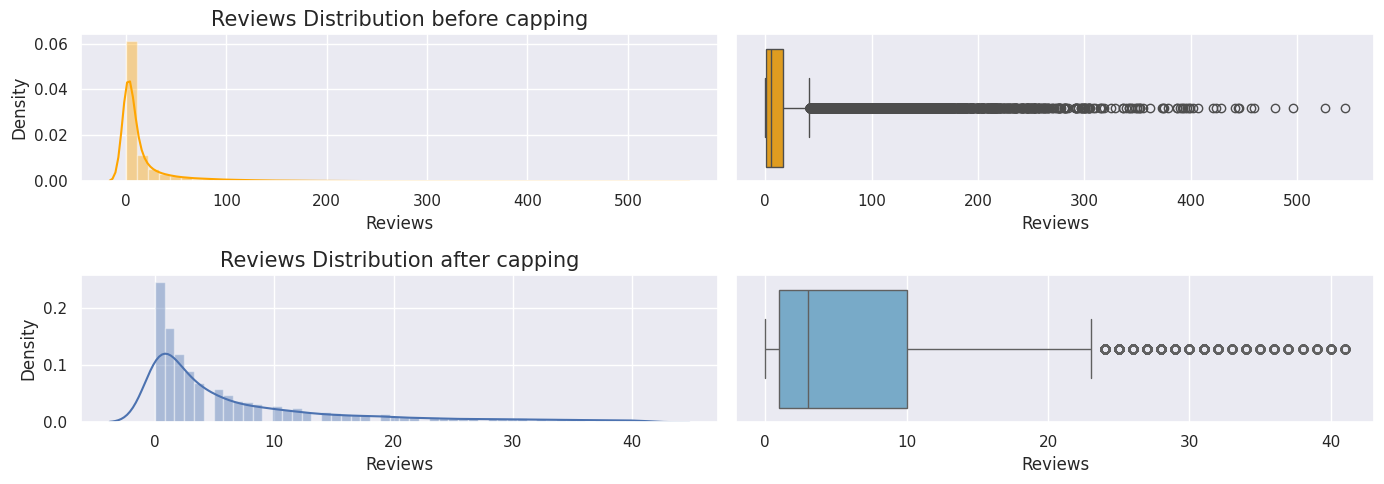

In [171]:
def dist_outliers(original_df, new, cols):
  for col in df_num_non_dummy:
      if col in cols:
        plt.figure(figsize=(14,5))

        plt.subplot(2,2,1)
        sns.distplot(original_df[col].dropna(), color='orange')
        plt.title('{} Distribution before capping'.format(col), fontsize=15)

        plt.subplot(2,2,2)
        sns.boxplot(x=original_df[col].dropna(), color='orange')
        plt.subplots_adjust(hspace = 0.6)

        plt.subplot(2,2,3)
        sns.distplot(new[col].dropna())
        plt.title('{} Distribution after capping'.format(col), fontsize=15)

        plt.subplot(2,2,4)
        sns.boxplot(x=new[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.tight_layout()
        plt.show()

dist_outliers(df, temp, outliers_df.index)

We clearly need to filter some features that either the feature distribution has changed significantly, or cases where removing outliers results with only one value.

Checking if distribution (Kolmogorov–Smirnov) and/or correlation has changed significantly:

In [172]:
### differences between two correlation in Python: https://github.com/psinger/CorrelationStats
### We will only take from the code the Fisher method for two-tailed test
### Z-test to Compare Two Correlations???
def cocor(x1,y1, x2,y2):
    xy1 = x1.corr(y1, method='spearman')
    xy2 = x2.corr(y2, method='spearman')
    n1 = len(x1)
    n2 = len(x2)
    xy_z = 0.5 * np.log((1 + xy1)/(1 - xy1))
    ab_z = 0.5 * np.log((1 + xy2)/(1 - xy2))
    if n2 is None:
        n2 = n1
    se_diff_r = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    diff = xy_z - ab_z
    z_score = abs(diff / se_diff_r)
    p_value = (1 - norm.cdf(z_score)) * 2
    return z_score, p_value

In [173]:
df_outliers[df_outliers['Checkin Rating']==1]['Checkin Rating'].sum()

np.int64(3697)

In [174]:
c=df_num_non_dummy.drop(columns=['Price'])
names=c.columns
#Creating df that reflects the correlation change
out_df= pd.DataFrame(columns=['feature','outliers_cnt','distribution_changed','correlation_changed'])

#A copy of numeric df
no_outliers=df_num_non_dummy.copy()
np.seterr(divide='ignore', invalid='ignore')
for i in names:
    # df with outliers
    out=df[i]
    # df with out outliers
    non=df[i].loc[df_outliers[i]==0]
    # lable with outliers
    price_out=df['Price']
    # lable with out outliers
    price_non=df['Price'].loc[df_outliers[i]==0]
    # cocor pvalue
    p, pvalue = cocor(out,price_out, non,price_non)
    cor_change=np.where(pvalue<0.05,'+','-')
    # outliers count
    # mv=df_outliers[df_outliers[i]==1].sum()
    mv=df_outliers[df_outliers[i]==1][i].sum()
    # ks pvalue
    pval=ks_2samp(out, non)[1]
    dist_change=np.where(pval<0.05,'+','-')
    out_df = pd.concat([out_df, pd.DataFrame([{'feature':i,'outliers_cnt':mv,'distribution_changed':dist_change,'correlation_changed': cor_change}])], ignore_index=True)

out_df.head(20)

,feature,outliers_cnt,distribution_changed,correlation_changed
0,Accuracy Rating,4357,-,-
1,Bathrooms,2793,-,-
2,Checkin Rating,3697,-,-
3,Cleanliness Rating,940,-,+
4,Communication Rating,3418,-,-
5,Host Response Rate,2181,-,+
6,Latitude,328,-,-
7,Location Rating,301,-,-
8,Longitude,782,+,-
9,Overall Rating,461,-,-


In [175]:
#All 'Yes' Vars in the 'Drop'colums shall be deleted, since the infect correlation and distribution.
#We don't want to delete vars that will change the distribution
out_df['drop']='yes'
out_df.loc[(out_df.distribution_changed=='+')& (out_df.correlation_changed=='+'),'drop'] = 'no'
out_df

,feature,outliers_cnt,distribution_changed,correlation_changed,drop
0,Accuracy Rating,4357,-,-,yes
1,Bathrooms,2793,-,-,yes
2,Checkin Rating,3697,-,-,yes
3,Cleanliness Rating,940,-,+,yes
4,Communication Rating,3418,-,-,yes
5,Host Response Rate,2181,-,+,yes
6,Latitude,328,-,-,yes
7,Location Rating,301,-,-,yes
8,Longitude,782,+,-,yes
9,Overall Rating,461,-,-,yes


In [176]:
out_df.groupby('drop').size()

,0
drop,
no,3
yes,15


There are 20 features in total where removal of the outliers does not affect neither correlation nor distribution. And 17 features that shall be removed.

In [177]:
relevant_columns_features=out_df.loc[out_df['drop']=='yes']['feature']
relevant_columns_features.values

array(['Accuracy Rating', 'Bathrooms', 'Checkin Rating',
       'Cleanliness Rating', 'Communication Rating', 'Host Response Rate',
       'Latitude', 'Location Rating', 'Longitude', 'Overall Rating',
       'Square Feet', 'Value Rating', 'Bedrooms', 'Beds',
       'Guests Included'], dtype=object)

Will only select the following columns to remove

In [178]:
remove_outliers=['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']
remove_outliers

['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']

Removing outleirs that don't change correlation

In [179]:
manipulated_data= df.copy()
for index, row in df_outliers.iterrows():  # Iterate through df_outliers with index
    for col in remove_outliers:
        if row[col] == 1:
            manipulated_data.loc[index,col] = np.nan ## 0  # Use the index from df_outliers

manipulated_data.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'Comments', 'Host Since',
       'Host Response Time', 'Is Superhost', 'neighbourhood',
       'Neighborhood Group', 'Postal Code', 'Is Exact Location',
       'Property Type', 'Room Type', 'Instant Bookable', 'Accomodates',
       'Bedrooms', 'Beds', 'Guests Included', 'Min Nights', 'Reviews',
       'Property Type Reduced', 'Postal Code Reduced'],
      dtype='object')

In [180]:
manipulated_data.to_csv('/content/drive/My Drive/Airbnb/manipulated_data_no_outleirs.csv')

## Missing Values

In [181]:
def missing_columns_df(df):
  df_nulls = df.copy()
  for col in df_nulls:
      if df_nulls[col].isna().sum() == 0:
          del df_nulls[col]
  return df_nulls

df_nulls = missing_columns_df(manipulated_data)
df_nulls

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Location Rating,Overall Rating,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Accomodates,Bedrooms,Beds,Min Nights
0,10.0,1.0,10.0,10.0,10.0,NaN,9.0,100.0,NaN,10.0,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,2.0,1.0,1.0,2.0
1,9.0,1.0,9.0,9.0,9.0,NaN,10.0,92.0,720.0,9.0,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,4.0,1.0,2.0,NaN
2,10.0,1.0,10.0,10.0,10.0,100.0,10.0,96.0,NaN,10.0,I could not have asked for a better place to s...,05-16-09,within an hour,2.0,1.0,2.0,2.0
3,10.0,NaN,10.0,10.0,10.0,100.0,10.0,100.0,NaN,10.0,The host was very welcoming and hospitable. He...,08-25-09,within a day,NaN,4.0,7.0,6.0
4,10.0,1.0,9.0,10.0,10.0,100.0,9.0,93.0,NaN,9.0,"We had everything we needed, the apartment was...",11-18-09,within a day,1.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,10-23-18,within a few hours,3.0,1.0,2.0,NaN
23532,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None,2.0,2.0,2.0,5.0
23533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,07-31-14,None,1.0,1.0,1.0,2.0
23534,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None,NaN,3.0,4.0,2.0


<Axes: >

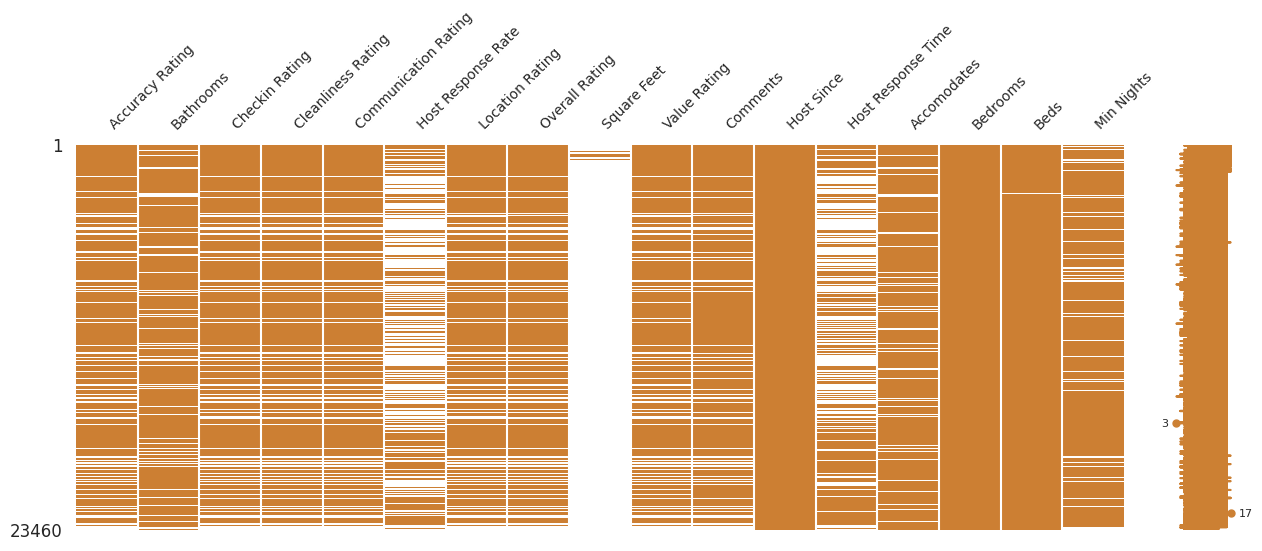

In [182]:
msno.matrix(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

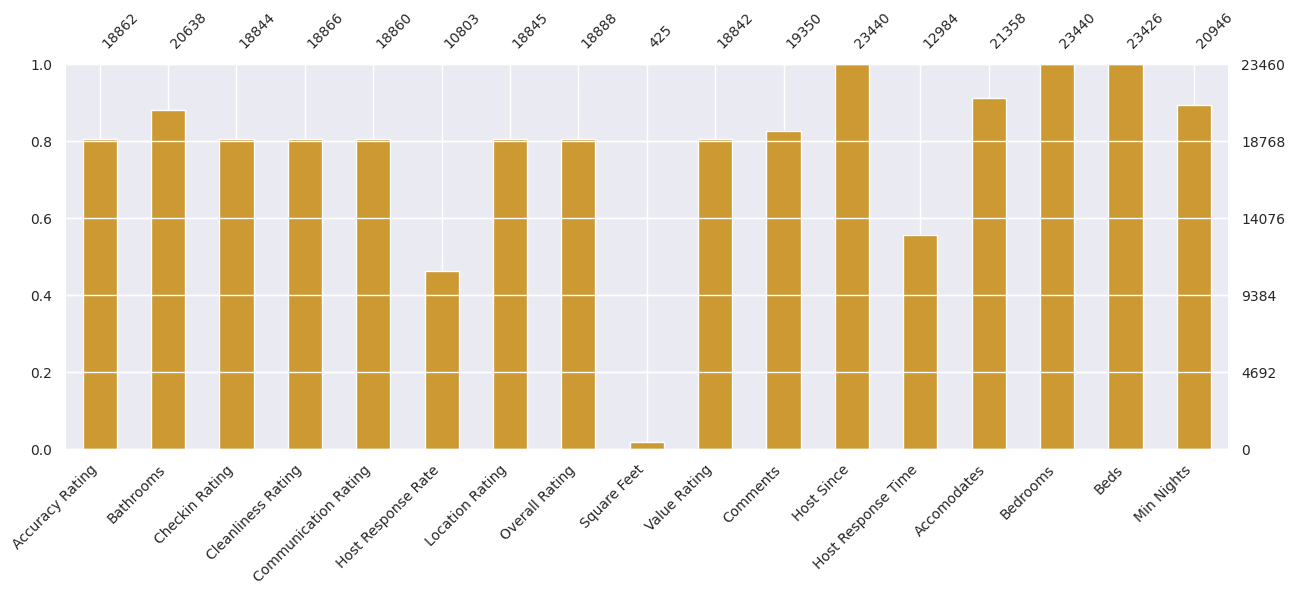

In [183]:
msno.bar(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.6, 0.2));

In [184]:
def missing_values_table(df):
  mis_val = df.isna().sum()
  mis_val_per = mis_val/len(df)*100
  mis_val_table = pd.concat([mis_val, mis_val_per], axis=1)
  mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
  mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,:] != 0].sort_values(
      '% of Total Values', ascending=False).round(1)
  return mis_val_table_ren_columns

mis_val_table_ren_columns = missing_values_table(df_nulls)

In [185]:
df_missing_data = manipulated_data.isin([np.nan])
df_missing_data = df_missing_data.astype('int')
df_missing_data

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,1,0,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
23532,1,0,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23533,1,1,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23534,1,0,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [186]:
#Selecting numeric data
numeric_manipulated_data = manipulated_data.select_dtypes(include=[np.number])
numeric_manipulated_data.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'Accomodates', 'Bedrooms', 'Beds',
       'Guests Included', 'Min Nights', 'Reviews'],
      dtype='object')

### Exploring data

Difference in the distribution of a variable when another variable is with or without MV:

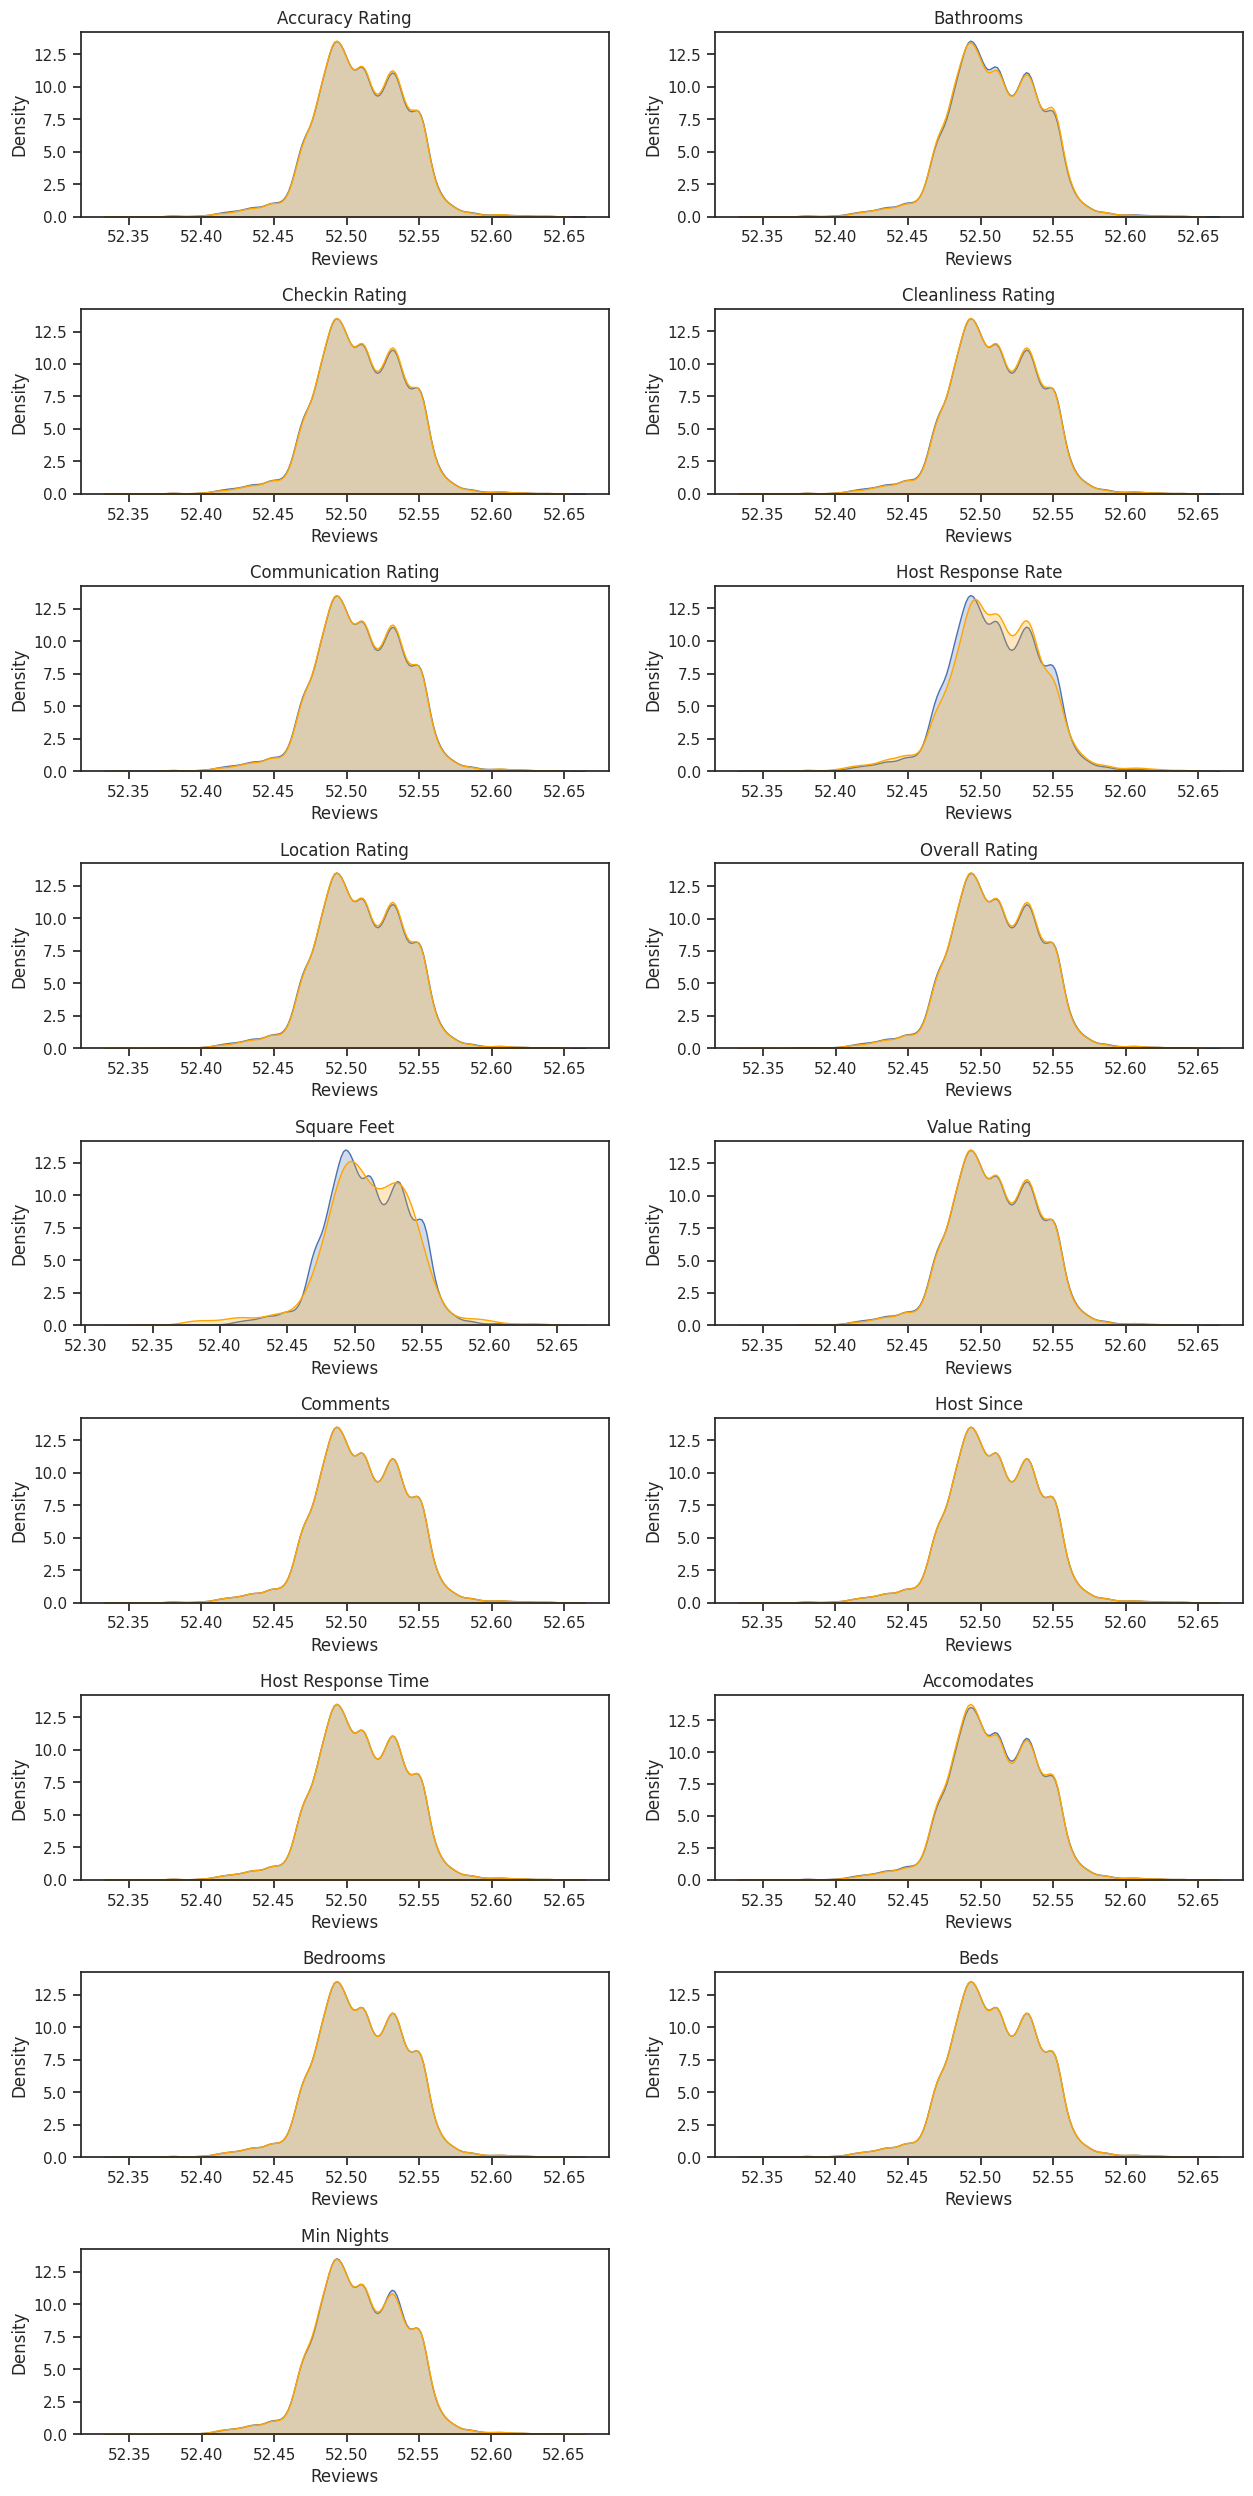

In [187]:
colist = df_nulls.columns
sns.set_style("ticks")
sns.set
a=len(colist)
b=2
c=1
fig = plt.figure(figsize=(15,60))
plt.subplots_adjust(hspace=0.5)
for j in df_nulls:
    plt.subplot(a,b,c)
    plt.title('{}'.format(j),fontsize=12)
    plt.xlabel(i)
    sns.kdeplot(df['Latitude'],fill=True)
    sns.kdeplot(df['Latitude'].loc[df_missing_data[j]==0],fill=True,color='orange')
    c=c+1

plt.show()

Exploring data of the segnificunce of distribution change:

In [188]:
#le = preprocessing.LabelEncoder()
MV_df_final = pd.DataFrame(columns= ['Var', 'MV_pct', 'distribution_changed', 'pval'])
#df[m] = le.fit_transform(df[m].astype(str))
m=numeric_manipulated_data.copy()
#m = manipulated_data._get_numeric_data().columns.dropna().unique()
np.seterr(divide='ignore', invalid='ignore')
for i in df_nulls:
    # and i in mis_val_table_ren_columns.index.tolist():
    # column with NULLS
        null = m['Latitude'] ##.loc[df_missing_data[i]==1]
    # column without NULLS
        non = m['Latitude'].loc[df_missing_data[i]==0]
    # target value with NULLS
        price_null = m['Price']
    # target value without NULLS
        price_non = price_null.loc[df_missing_data[i]==0]
        mv = df_missing_data[i].sum()
    # perform Kolmogorov-Smirnov test
        pval = ks_2samp(null, non)[1]
        dis_change = np.where(pval<0.05,'+','-')
        # MV_df_final = pd.concat([MV_df_final, pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change}, index=[0])], ignore_index=True)
        temp_df = pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change, 'pval': pval}, index=[0])
        # Concatenate the temporary DataFrame to the final DataFrame
        MV_df_final = pd.concat([MV_df_final, temp_df], ignore_index=True)
        MV_df_final = MV_df_final[MV_df_final['MV_pct'] > 0]

        ## Plot KDE for comparison
        # plt.figure(figsize=(10, 5))
        # sns.kdeplot(null, label="is NaN", fill=True, alpha=0.5, color='blue')
        # sns.kdeplot(non, label="is NOT NaN", fill=True, alpha=0.5, color='red')
        # plt.title(f"Distribution of Missingness of '{i}' , P-Value = {pval}, Missing= {mv}")
        # plt.legend()
        # plt.show()
MV_df_final

,Var,MV_pct,distribution_changed,pval
0,Accuracy Rating,4598,-,0.975353
1,Bathrooms,2822,-,0.990963
2,Checkin Rating,4616,-,0.972590
3,Cleanliness Rating,4594,-,0.974126
4,Communication Rating,4600,-,0.973198
5,Host Response Rate,12657,+,0.000001
6,Location Rating,4615,-,0.972268
7,Overall Rating,4572,-,0.972818
8,Square Feet,23035,-,0.313684
9,Value Rating,4618,-,0.973239


In [189]:
MV_df_final['drop']= 'Yes'
MV_df_final['MV_type']= 'MCAR/MAR'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'drop']='No'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'MV_type']='MNAR'
MV_df_final = MV_df_final[MV_df_final['MV_pct']>0].sort_values(by='MV_pct', ascending=False)
MV_df_final

,Var,MV_pct,distribution_changed,pval,drop,MV_type
8,Square Feet,23035,-,0.313684,Yes,MCAR/MAR
5,Host Response Rate,12657,+,0.000001,No,MNAR
9,Value Rating,4618,-,0.973239,Yes,MCAR/MAR
2,Checkin Rating,4616,-,0.972590,Yes,MCAR/MAR
6,Location Rating,4615,-,0.972268,Yes,MCAR/MAR
4,Communication Rating,4600,-,0.973198,Yes,MCAR/MAR
0,Accuracy Rating,4598,-,0.975353,Yes,MCAR/MAR
3,Cleanliness Rating,4594,-,0.974126,Yes,MCAR/MAR
7,Overall Rating,4572,-,0.972818,Yes,MCAR/MAR
1,Bathrooms,2822,-,0.990963,Yes,MCAR/MAR


## Data Imputation

Although the columns were recommended for removal, we will go over teh columns one by one.

In [190]:
mis_val_table_ren_columns

,Missing Values,% of Total Values
Square Feet,23035,98.2
Host Response Rate,12657,54.0
Host Response Time,10476,44.7
Value Rating,4618,19.7
Checkin Rating,4616,19.7
Location Rating,4615,19.7
Communication Rating,4600,19.6
Accuracy Rating,4598,19.6
Cleanliness Rating,4594,19.6
Overall Rating,4572,19.5


In [191]:
df_final = manipulated_data

In [192]:
manipulated_data.reset_index(drop=True, inplace=True)

1. We will delete 'Host Response Rate' since the missing is nearly 50%, however we will try to keep 'Host Response Time', cause we might use it later

In [193]:
del df_final['Host Response Rate']
del df_final['Square Feet']

2. We will categorize the missing values of dummies and categorial values: host_has_profile_pic, host_identity_verified, host_is_superhost, host_response_time, host_neighbourhood, host_location.
2.1 Transporing missing values of 3 categorial columns into additional categoey 'Missing'

In [194]:
#host_response_time
# df_final['Host Response Time'] = df_final.apply(lambda row: row['Host Response Time'] if type(row['Host Response Time']) == str else 'missing', axis=1)
df_final['Host Response Time'] = df_final['Host Response Time'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Host Response Time'].isnull().sum()

np.int64(0)

In [195]:
#host_response_time
df_final['Comments'] = df_final['Comments'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Comments'].isnull().sum()

np.int64(0)

In [196]:
missing_values_table(missing_columns_df(df_final))

,Missing Values,% of Total Values
Value Rating,4618,19.7
Checkin Rating,4616,19.7
Location Rating,4615,19.7
Communication Rating,4600,19.6
Accuracy Rating,4598,19.6
Cleanliness Rating,4594,19.6
Overall Rating,4572,19.5
Bathrooms,2822,12.0
Min Nights,2514,10.7
Accomodates,2102,9.0


### Use KNN

The rest of the data is below 40% missing. hense we can imput. we will use KNN

In [197]:
final_df = df_final.copy()
imp_cols = final_df.select_dtypes(include = ['float64', 'int64']).columns
imp_cols = [col for col in imp_cols if col not in ['Longitude', 'Latitude']]
imp_cols

['Accuracy Rating',
 'Bathrooms',
 'Checkin Rating',
 'Cleanliness Rating',
 'Communication Rating',
 'Location Rating',
 'Overall Rating',
 'Price',
 'Value Rating',
 'Accomodates',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews']

In [198]:
import math
math.sqrt(math.sqrt(len(final_df)))

12.376048480365869

In [199]:
from sklearn.impute import KNNImputer
# metric='nan_euclidean'
knn_imputer = KNNImputer(n_neighbors=11, metric='nan_euclidean')
imputed_data = pd.DataFrame(knn_imputer.fit_transform(final_df[imp_cols]),columns = imp_cols)

In [200]:
final_df[imp_cols] = imputed_data

<Axes: >

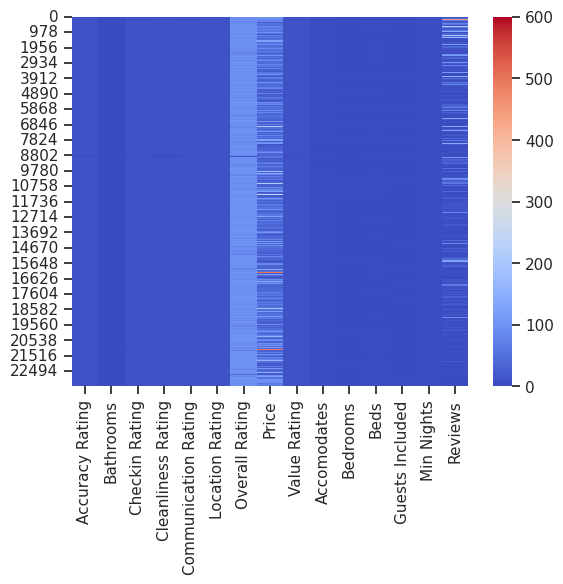

In [201]:
sns.heatmap(imputed_data, cmap="coolwarm")

In [202]:
imputed_data['Overall Rating'].notna().sum()

np.int64(23460)

In [203]:
imputed_data

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Location Rating,Overall Rating,Price,Value Rating,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews
0,10.000000,1.0,10.000000,10.000000,10.000000,9.000000,100.000000,17.0,10.000000,2.000000,1.0,1.0,1.0,2.000000,7.0
1,9.000000,1.0,9.000000,9.000000,9.000000,10.000000,92.000000,90.0,9.000000,4.000000,1.0,2.0,2.0,1.727273,144.0
2,10.000000,1.0,10.000000,10.000000,10.000000,10.000000,96.000000,33.0,10.000000,2.000000,1.0,2.0,1.0,2.000000,229.0
3,10.000000,1.0,10.000000,10.000000,10.000000,10.000000,100.000000,180.0,10.000000,3.636364,4.0,7.0,5.0,6.000000,6.0
4,10.000000,1.0,9.000000,10.000000,10.000000,9.000000,93.000000,70.0,9.000000,1.000000,0.0,1.0,1.0,2.454545,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23455,9.818182,1.0,10.000000,9.636364,9.818182,9.818182,96.363636,48.0,9.090909,3.000000,1.0,2.0,1.0,2.363636,0.0
23456,9.272727,1.0,9.272727,8.363636,9.636364,8.909091,90.909091,30.0,9.090909,2.000000,2.0,2.0,2.0,5.000000,0.0
23457,9.636364,1.0,9.818182,9.454545,10.000000,9.272727,96.363636,17.0,8.909091,1.000000,1.0,1.0,1.0,2.000000,0.0
23458,9.272727,1.0,9.818182,9.363636,9.636364,9.363636,90.000000,52.0,8.363636,3.272727,3.0,4.0,1.0,2.000000,0.0


<Axes: >

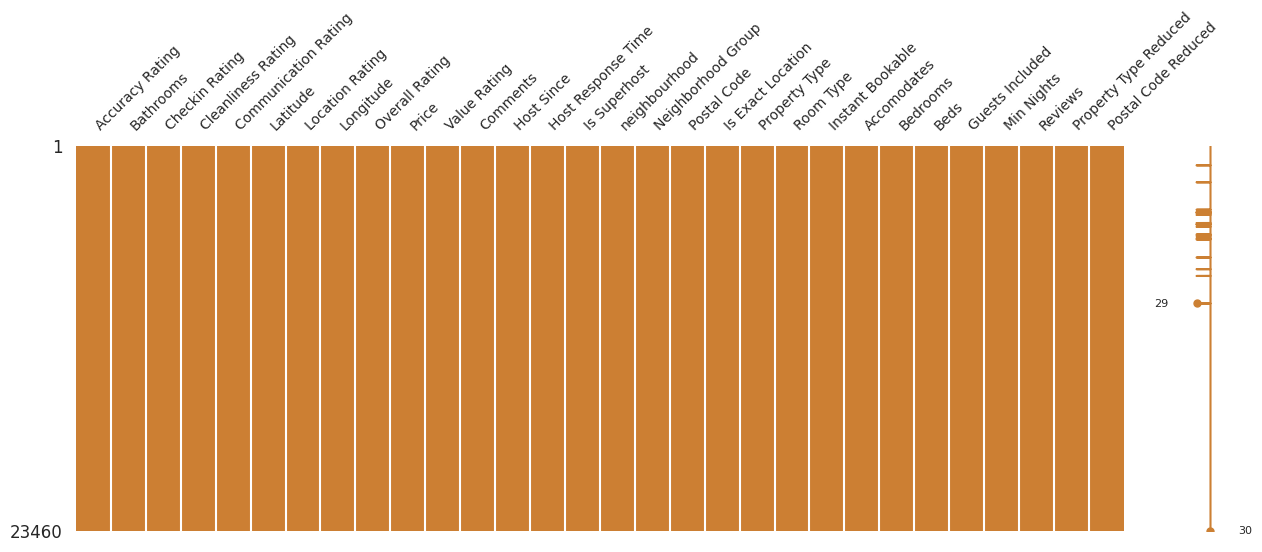

In [204]:
msno.matrix(final_df, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

# Next to Aggregation and Feature Engineering

In [205]:
final_df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl")

In [206]:
# df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')
# df_Feature_Engineering.info()